# This is Framework

# START

# 0.00 | INFO & IMPORT

In [ ]:
# Install necessary libraries
!pip install yfinance TA-Lib

In [ ]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from statsmodels.regression.linear_model import OLS
from statsmodels.tsa.stattools import coint
import statsmodels as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS, MeanShift, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.optimize import minimize
import talib

# Data handling
import pandas as pd
import numpy as np

# Data sources
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics & time series
import scipy.stats as stats
from scipy.stats import skew, kurtosis
from statsmodels.regression.linear_model import OLS
from statsmodels.tsa.stattools import coint
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# Technical Analysis
import talib


# Machine learning / preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# -- | Import my Functions

In [ ]:
from google.colab import drive
drive.mount('/content/drive')   # ✅ always mount here

# Then go to your Colab Notebooks folder
%cd /content/drive/MyDrive/Colab Notebooks

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks


In [ ]:
%run Quant_Invest_Framework_1.ipynb

# 01.00 | PARAMETERS

In [ ]:

tickers_interested = [
    "BTC-USD",
    "ETH-USD",
    "XRP-USD",
    "BNB-USD",
    "SOL-USD",
    "ADA-USD",
]

tickers_interested = [

"SPXL",


]



ticker_top =  ["SPXL"]




# Use pandas Timestamp (no timezone unless you want it)
start_date_download = pd.Timestamp("2015-01-01", tz="UTC")
end_date_download   = pd.Timestamp("2026-01-01", tz="UTC")

start_date = pd.Timestamp("2018-01-01", tz="UTC")
end_date   = pd.Timestamp("2026-01-01", tz="UTC")



split_date = pd.Timestamp("2025-01-01", tz="UTC")

# 02.00 | Data

In [ ]:
# Download data (daily data for the last year)
df_data_raw = yf.download(tickers_interested, start=start_date, end=end_date, auto_adjust=False)
#df_data_raw_long = yf.download(tickers_download, start=start_date_download, end=end_date_download, auto_adjust=False)

#df_data_raw = yf.download(tickers_interested, period = "730d", auto_adjust=False, interval = "4h")

[*********************100%***********************]  1 of 1 completed


In [ ]:
if df_data_raw.index.tz is None:
    df_data_raw.index = df_data_raw.index.tz_localize("UTC")
else:
    # If already tz-aware → convert to UTC
    df_data_raw.index = df_data_raw.index.tz_convert("UTC")

df_data_raw_long = df_data_raw.copy()

In [ ]:
df_data_raw_long

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPXL,SPXL,SPXL,SPXL,SPXL,SPXL
Date,,,,,,
2018-01-02 00:00:00+00:00,42.839581,45.189999,45.189999,44.500000,44.730000,1826300
2018-01-03 00:00:00+00:00,43.597977,45.990002,46.090000,45.250000,45.270000,2150800
2018-01-04 00:00:00+00:00,44.147800,46.570000,46.869999,46.320000,46.380001,2632000
2018-01-05 00:00:00+00:00,44.982037,47.450001,47.560001,46.740002,47.029999,1928900
2018-01-08 00:00:00+00:00,45.256958,47.740002,47.820000,47.250000,47.419998,1992500
...,...,...,...,...,...,...
2025-09-04 00:00:00+00:00,196.220001,196.220001,196.350006,191.360001,192.220001,2387200
2025-09-05 00:00:00+00:00,194.220001,194.220001,199.029999,190.949997,198.320007,6581800


In [ ]:
# Compute log returns for selected tickers
df_log_returns_TARGET = np.log(
    df_data_raw_long['Adj Close'][tickers_interested] /
    df_data_raw_long['Adj Close'][tickers_interested].shift(1)
)

# 03.00 | Data Visulisation

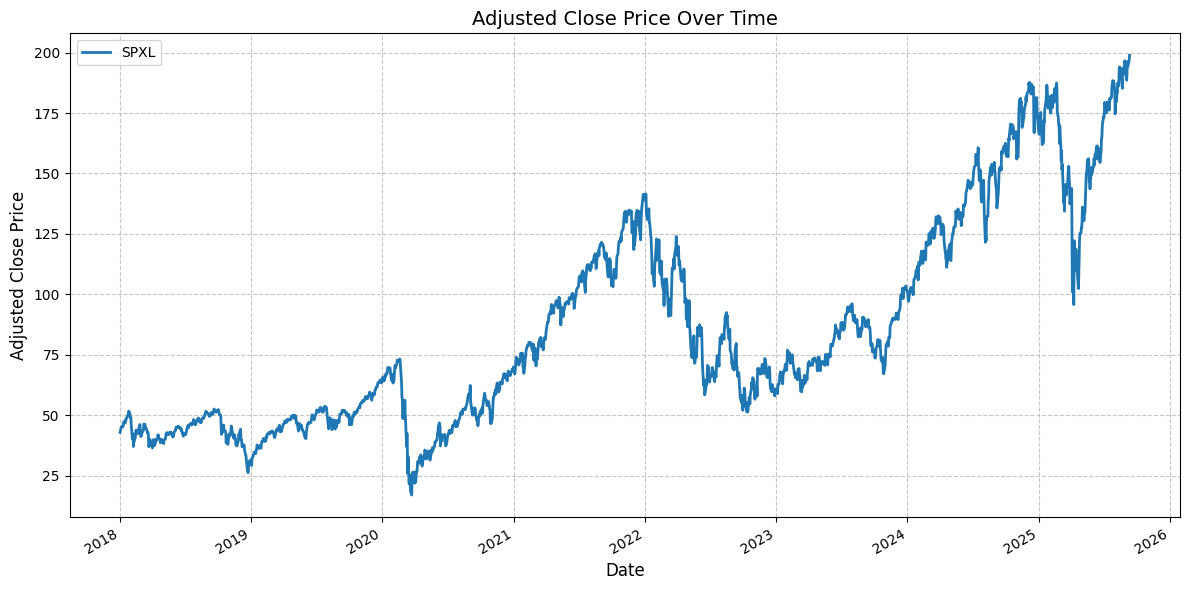

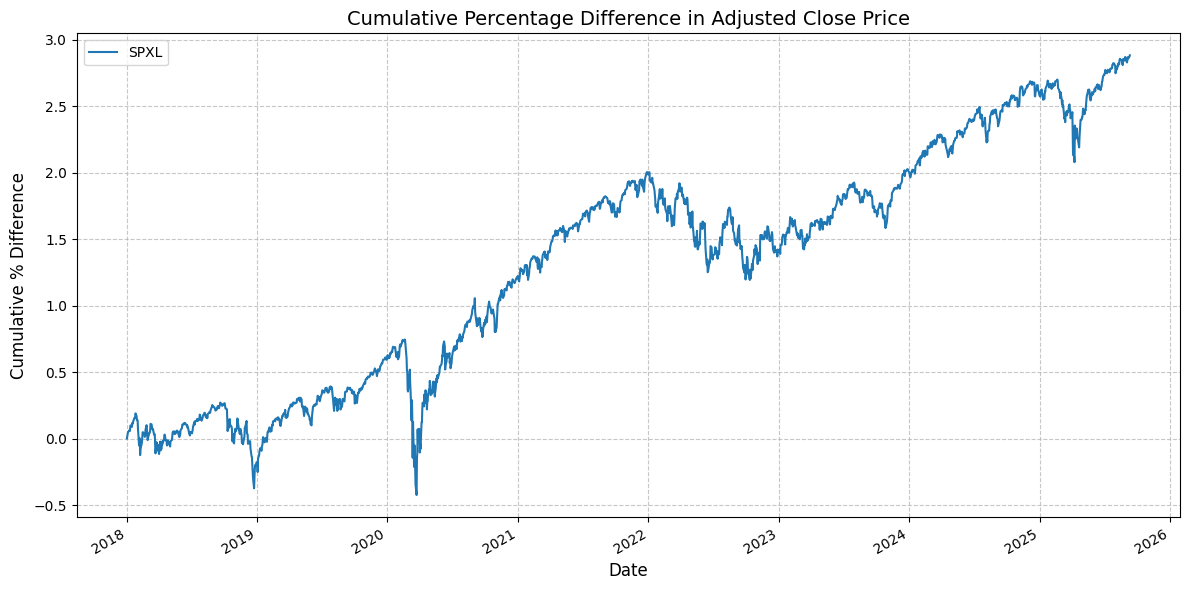

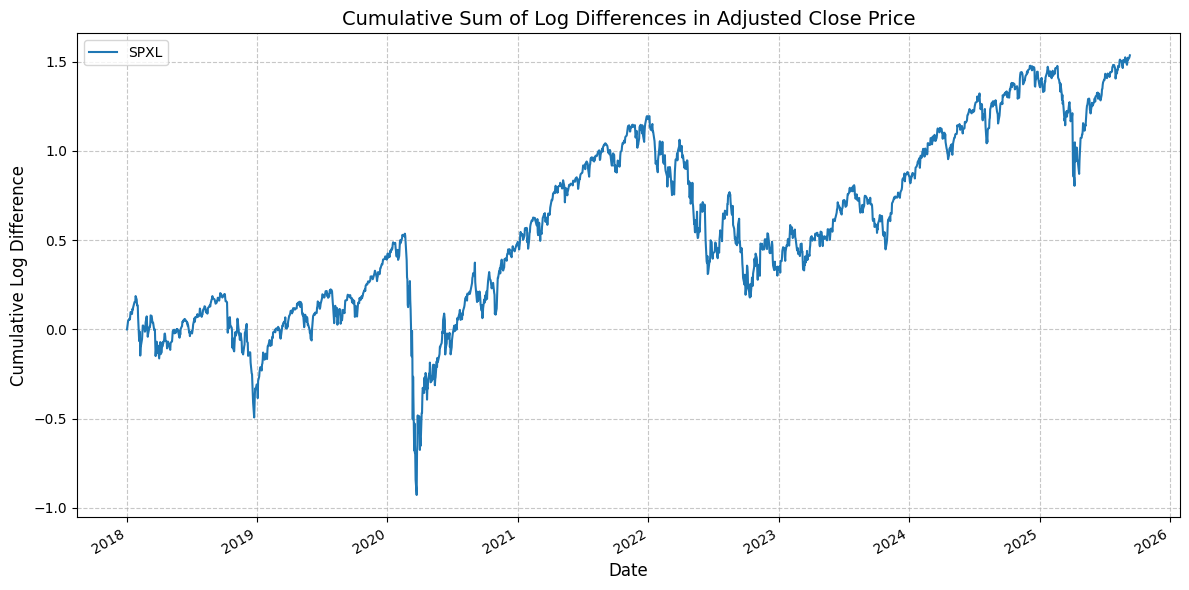

In [ ]:
Analyze_price(tickers_interested, df_data_raw)

In [ ]:
#Analyze_price_2(tickers_interested, df_data_raw)

In [ ]:
#Analyze_price_return_dynamics(tickers_interested, df_data_raw)

In [ ]:
#Analyze_asset_relationships(tickers_interested, df_data_raw)

In [ ]:
#Analyze_volume_liquidity_and_stylized_facts(tickers_interested, df_data_raw)

# What if i measure what will happen if you ommit 10 percents of worst or best days

# 04.00 | FE Engineer

In [ ]:
df_data_raw.head(3)

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPXL,SPXL,SPXL,SPXL,SPXL,SPXL
Date,,,,,,
2018-01-02 00:00:00+00:00,42.839581,45.189999,45.189999,44.50,44.730000,1826300
2018-01-03 00:00:00+00:00,43.597977,45.990002,46.090000,45.25,45.270000,2150800
2018-01-04 00:00:00+00:00,44.147800,46.570000,46.869999,46.32,46.380001,2632000


In [ ]:
df_data_raw.tail(3)

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPXL,SPXL,SPXL,SPXL,SPXL,SPXL
Date,,,,,,
2025-09-08 00:00:00+00:00,195.949997,195.949997,196.770004,194.440002,195.669998,2170300
2025-09-09 00:00:00+00:00,197.160004,197.160004,197.619995,194.369995,195.929993,3257300
2025-09-10 00:00:00+00:00,198.910004,198.910004,200.949997,197.399994,200.080002,3479900




```
# Init
fe = FeatureEngineerTA(df_data_raw_long, ["AAPL", "SPY"])

features = (fe
    # Moving average log distances
    .add_EMA_log_dist([10, 20, 40, 60])
    .add_SMA_log_dist([10, 20, 40, 60])

    # Momentum indicators
    .add_RSI([14, 28, 56])
    .add_MACD_log_dist([
        (12, 26, 9),
        (5, 35, 5),
        (50, 80, 5),
        (8, 21, 5)
    ])
    .add_STOCH([
        (14, 3, 3),
        (21, 5, 5)
    ])
    .add_WILLR(14)
    .add_WILLR(20)

    # Lagged returns and statistics
    .add_lagged_features_returns(
        log_returns_lags=[1, 2, 3, 5],
        rolling_windows=[3, 7, 14, 21],
        cumdiff_windows=[3, 5, 7, 9, 15, 40]
    )
    .add_rolling_percentile(window=120, ma_window=10)

    # Volatility
    .add_BBANDS(n=20, nbdevup=2, nbdevdn=2)

    # Volume-based
    .add_MFI(14)
    .add_MFI(28)
)


# Get final feature set
features = fe.get_features()
```



In [ ]:
# Init
fe = FeatureEngineerTA(df_data_raw_long, tickers_interested)

features = (fe
    # Moving average log distances
    .add_EMA_log_dist([10, 20, 40, 60])
    .add_SMA_log_dist([10, 20, 40, 60])

    # Momentum indicators
    .add_RSI([14, 28, 56])
    .add_MACD_log_dist([
        (12, 26, 9),
        (5, 35, 5),
        (8, 21, 5)
    ])
    .add_STOCH([
        (14, 3, 3),
        (21, 5, 5)
    ])
    .add_WILLR(14)
    .add_WILLR(20)

    # Lagged returns and statistics
    .add_lagged_features_returns(
        log_returns_lags=[1, 2, 3, 5],
        rolling_windows=[3, 7, 14, 21],
        cumdiff_windows=[3, 5, 7, 9, 15, 40]
    )
    .add_rolling_percentile(window=30, ma_window=2)

    # Volatility
    #.add_BBANDS(n=20, nbdevup=2, nbdevdn=2)

    # Volume-based
    .add_MFI(14)
    .add_MFI(28)
)


# Get final feature set
df_features = fe.get_features()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(uf

In [ ]:
df_features.head(3)

Ticker                                    SPXL                   \
Feature                   Adj Close_pctMA_30_2 Adj Close_pct_30   
Date                                                              
2018-01-02 00:00:00+00:00                  NaN              NaN   
2018-01-03 00:00:00+00:00                  NaN              NaN   
2018-01-04 00:00:00+00:00                  NaN              NaN   

Ticker                                                                     \
Feature                   EMA_log_dist_10 EMA_log_dist_20 EMA_log_dist_40   
Date                                                                        
2018-01-02 00:00:00+00:00             NaN             NaN             NaN   
2018-01-03 00:00:00+00:00             NaN             NaN             NaN   
2018-01-04 00:00:00+00:00             NaN             NaN             NaN   

Ticker                                                                        \
Feature                   EMA_log_dist_60 MACD_hist_12_26_9 MACD_hist_5_35_5   
Date                                                                           
2018-01-02 00:00:00+00:00             NaN               NaN              NaN   
2018-01-03 00:00:00+00:00             NaN               NaN              NaN   
2018-01-04 00:00:00+00:00             NaN               NaN              NaN   

Ticker                                                            ...  \
Feature                   MACD_hist_8_21_5 MACD_log_dist_12_26_9  ...   
Date                                                              ...   
2018-01-02 00:00:00+00:00              NaN                   NaN  ...   
2018-01-03 00:00:00+00:00              NaN                   NaN  ...   
2018-01-04 00:00:00+00:00              NaN                   NaN  ...   

Ticker                                                                   \
Feature                   ret_mean_3 ret_mean_7 ret_skew_14 ret_skew_21   
Date                                                                      
2018-01-02 00:00:00+00:00        NaN        NaN         NaN         NaN   
2018-01-03 00:00:00+00:00        NaN        NaN         NaN         NaN   
2018-01-04 00:00:00+00:00        NaN        NaN         NaN         NaN   

Ticker                                                                 \
Feature                   ret_skew_3 ret_skew_7 ret_std_14 ret_std_21   
Date                                                                    
2018-01-02 00:00:00+00:00        NaN        NaN        NaN        NaN   
2018-01-03 00:00:00+00:00        NaN        NaN        NaN        NaN   
2018-01-04 00:00:00+00:00        NaN        NaN        NaN        NaN   

Ticker                                         
Feature                   ret_std_3 ret_std_7  
Date                                           
2018-01-02 00:00:00+00:00       NaN       NaN  
2018-01-03 00:00:00+00:00       NaN       NaN  
2018-01-04 00:00:00+00:00       NaN       NaN  

[3 rows x 48 columns]

In [ ]:
df_features.tail(3)

Ticker                                    SPXL                   \
Feature                   Adj Close_pctMA_30_2 Adj Close_pct_30   
Date                                                              
2025-09-08 00:00:00+00:00             0.913793         0.931034   
2025-09-09 00:00:00+00:00             0.965517         1.000000   
2025-09-10 00:00:00+00:00             1.000000         1.000000   

Ticker                                                                     \
Feature                   EMA_log_dist_10 EMA_log_dist_20 EMA_log_dist_40   
Date                                                                        
2025-09-08 00:00:00+00:00        0.013291        0.023787        0.051408   
2025-09-09 00:00:00+00:00        0.015883        0.027052        0.054678   
2025-09-10 00:00:00+00:00        0.020180        0.032415        0.060321   

Ticker                                                                        \
Feature                   EMA_log_dist_60 MACD_hist_12_26_9 MACD_hist_5_35_5   
Date                                                                           
2025-09-08 00:00:00+00:00        0.080337         -0.200248         0.077424   
2025-09-09 00:00:00+00:00        0.083536         -0.075390         0.313189   
2025-09-10 00:00:00+00:00        0.089205          0.088908         0.608145   

Ticker                                                            ...  \
Feature                   MACD_hist_8_21_5 MACD_log_dist_12_26_9  ...   
Date                                                              ...   
2025-09-08 00:00:00+00:00         0.033627              4.157929  ...   
2025-09-09 00:00:00+00:00         0.162764              4.130079  ...   
2025-09-10 00:00:00+00:00         0.322787              4.081752  ...   

Ticker                                                                   \
Feature                   ret_mean_3 ret_mean_7 ret_skew_14 ret_skew_21   
Date                                                                      
2025-09-08 00:00:00+00:00   0.007570   0.000944    0.754841    0.593032   
2025-09-09 00:00:00+00:00   0.001593   0.000355    0.619052    0.718655   
2025-09-10 00:00:00+00:00   0.007954   0.004302    0.430376    0.598503   

Ticker                                                                 \
Feature                   ret_skew_3 ret_skew_7 ret_std_14 ret_std_21   
Date                                                                    
2025-09-08 00:00:00+00:00  -0.337538  -0.239250   0.019153   0.017603   
2025-09-09 00:00:00+00:00  -1.599015  -0.140250   0.018449   0.017119   
2025-09-10 00:00:00+00:00  -1.731274  -0.824834   0.018179   0.017062   

Ticker                                         
Feature                   ret_std_3 ret_std_7  
Date                                           
2025-09-08 00:00:00+00:00  0.017203  0.018217  
2025-09-09 00:00:00+00:00  0.010341  0.017930  
2025-09-10 00:00:00+00:00  0.001557  0.015945  

[3 rows x 48 columns]

## Train test split



*   Data shifted
*   Crop due to FE



In [ ]:
# --- Prepare features and target --- #
df_train_test_split = df_features.copy()

print("CHECK SHIFT!!!")
display(df_train_test_split.tail(3))                 # before shift
df_train_test_split = df_train_test_split.shift(1)   # align features with proper TARGET
display(df_train_test_split.tail(3))                 # after shift

df_log_returns_TARGET_split = df_log_returns_TARGET.copy()


# --- Crop data --- # Drop NA from past
df_train_test_split = Crop_df_by_date(df_train_test_split, start_date=start_date, end_date=end_date)
df_log_returns_TARGET_split = Crop_df_by_date(df_log_returns_TARGET_split, start_date=start_date, end_date=end_date)

# Drop the first 120 rows
df_train_test_split = df_train_test_split.iloc[120:]
df_log_returns_TARGET_split = df_log_returns_TARGET_split.iloc[120:]


# --- Select features/targets --- #
df_train_test_split = df_train_test_split.xs(ticker_top[0], axis=1, level=0)  # SPY features
df_log_returns_TARGET_split = df_log_returns_TARGET_split[ticker_top]      # SPY log returns

df_log_ret_backtest = df_log_returns_TARGET_split.copy()

CHECK SHIFT!!!


Ticker                                    SPXL                   \
Feature                   Adj Close_pctMA_30_2 Adj Close_pct_30   
Date                                                              
2025-09-08 00:00:00+00:00             0.913793         0.931034   
2025-09-09 00:00:00+00:00             0.965517         1.000000   
2025-09-10 00:00:00+00:00             1.000000         1.000000   

Ticker                                                                     \
Feature                   EMA_log_dist_10 EMA_log_dist_20 EMA_log_dist_40   
Date                                                                        
2025-09-08 00:00:00+00:00        0.013291        0.023787        0.051408   
2025-09-09 00:00:00+00:00        0.015883        0.027052        0.054678   
2025-09-10 00:00:00+00:00        0.020180        0.032415        0.060321   

Ticker                                                                        \
Feature                   EMA_log_dist_60 MACD_hist_12_26_9 MACD_hist_5_35_5   
Date                                                                           
2025-09-08 00:00:00+00:00        0.080337         -0.200248         0.077424   
2025-09-09 00:00:00+00:00        0.083536         -0.075390         0.313189   
2025-09-10 00:00:00+00:00        0.089205          0.088908         0.608145   

Ticker                                                            ...  \
Feature                   MACD_hist_8_21_5 MACD_log_dist_12_26_9  ...   
Date                                                              ...   
2025-09-08 00:00:00+00:00         0.033627              4.157929  ...   
2025-09-09 00:00:00+00:00         0.162764              4.130079  ...   
2025-09-10 00:00:00+00:00         0.322787              4.081752  ...   

Ticker                                                                   \
Feature                   ret_mean_3 ret_mean_7 ret_skew_14 ret_skew_21   
Date                                                                      
2025-09-08 00:00:00+00:00   0.007570   0.000944    0.754841    0.593032   
2025-09-09 00:00:00+00:00   0.001593   0.000355    0.619052    0.718655   
2025-09-10 00:00:00+00:00   0.007954   0.004302    0.430376    0.598503   

Ticker                                                                 \
Feature                   ret_skew_3 ret_skew_7 ret_std_14 ret_std_21   
Date                                                                    
2025-09-08 00:00:00+00:00  -0.337538  -0.239250   0.019153   0.017603   
2025-09-09 00:00:00+00:00  -1.599015  -0.140250   0.018449   0.017119   
2025-09-10 00:00:00+00:00  -1.731274  -0.824834   0.018179   0.017062   

Ticker                                         
Feature                   ret_std_3 ret_std_7  
Date                                           
2025-09-08 00:00:00+00:00  0.017203  0.018217  
2025-09-09 00:00:00+00:00  0.010341  0.017930  
2025-09-10 00:00:00+00:00  0.001557  0.015945  

[3 rows x 48 columns]

Ticker                                    SPXL                   \
Feature                   Adj Close_pctMA_30_2 Adj Close_pct_30   
Date                                                              
2025-09-08 00:00:00+00:00             0.931034         0.896552   
2025-09-09 00:00:00+00:00             0.913793         0.931034   
2025-09-10 00:00:00+00:00             0.965517         1.000000   

Ticker                                                                     \
Feature                   EMA_log_dist_10 EMA_log_dist_20 EMA_log_dist_40   
Date                                                                        
2025-09-08 00:00:00+00:00        0.007401        0.017456        0.045249   
2025-09-09 00:00:00+00:00        0.013291        0.023787        0.051408   
2025-09-10 00:00:00+00:00        0.015883        0.027052        0.054678   

Ticker                                                                        \
Feature                   EMA_log_dist_60 MACD_hist_12_26_9 MACD_hist_5_35_5   
Date                                                                           
2025-09-08 00:00:00+00:00        0.074309         -0.306994        -0.174675   
2025-09-09 00:00:00+00:00        0.080337         -0.200248         0.077424   
2025-09-10 00:00:00+00:00        0.083536         -0.075390         0.313189   

Ticker                                                            ...  \
Feature                   MACD_hist_8_21_5 MACD_log_dist_12_26_9  ...   
Date                                                              ...   
2025-09-08 00:00:00+00:00        -0.097508              4.167730  ...   
2025-09-09 00:00:00+00:00         0.033627              4.157929  ...   
2025-09-10 00:00:00+00:00         0.162764              4.130079  ...   

Ticker                                                                   \
Feature                   ret_mean_3 ret_mean_7 ret_skew_14 ret_skew_21   
Date                                                                      
2025-09-08 00:00:00+00:00   0.009788   0.000590    0.892780    0.687681   
2025-09-09 00:00:00+00:00   0.007570   0.000944    0.754841    0.593032   
2025-09-10 00:00:00+00:00   0.001593   0.000355    0.619052    0.718655   

Ticker                                                                 \
Feature                   ret_skew_3 ret_skew_7 ret_std_14 ret_std_21   
Date                                                                    
2025-09-08 00:00:00+00:00  -1.295060  -0.176503   0.019034   0.017583   
2025-09-09 00:00:00+00:00  -0.337538  -0.239250   0.019153   0.017603   
2025-09-10 00:00:00+00:00  -1.599015  -0.140250   0.018449   0.017119   

Ticker                                         
Feature                   ret_std_3 ret_std_7  
Date                                           
2025-09-08 00:00:00+00:00  0.017870  0.018061  
2025-09-09 00:00:00+00:00  0.017203  0.018217  
2025-09-10 00:00:00+00:00  0.010341  0.017930  

[3 rows x 48 columns]

In [ ]:
print((type(df_train_test_split)))

<class 'pandas.core.frame.DataFrame'>


## **Train test split**

In [ ]:
df_x_train, df_x_test = Train_test_split(df_train_test_split, split_date)
df_y_train, df_y_test = Train_test_split(df_log_returns_TARGET_split, split_date)

df_log_ret_train_backtest, df_log_ret_test_backtest = Train_test_split(df_log_ret_backtest, split_date)

In [ ]:
df_log_ret_train_backtest.head()

Ticker,SPXL
Date,
2018-06-25 00:00:00+00:00,-0.040822
2018-06-26 00:00:00+00:00,0.005615
2018-06-27 00:00:00+00:00,-0.025634
2018-06-28 00:00:00+00:00,0.018666
2018-06-29 00:00:00+00:00,0.004501


In [ ]:
df_x_train.head(3)

Feature,Adj Close_pctMA_30_2,Adj Close_pct_30,EMA_log_dist_10,EMA_log_dist_20,EMA_log_dist_40,EMA_log_dist_60,MACD_hist_12_26_9,MACD_hist_5_35_5,MACD_hist_8_21_5,MACD_log_dist_12_26_9,...,ret_mean_3,ret_mean_7,ret_skew_14,ret_skew_21,ret_skew_3,ret_skew_7,ret_std_14,ret_std_21,ret_std_3,ret_std_7
Date,,,,,,,,,,,,,,,,,,,,,
2018-06-25 00:00:00+00:00,0.620690,0.620690,-0.010058,-0.001352,0.017347,0.022915,-0.200770,-0.415488,-0.245421,4.227784,...,-0.003156,-0.003406,0.245962,0.280671,-1.712337,-0.486493,0.010941,0.017060,0.014231,0.010034
2018-06-26 00:00:00+00:00,0.379310,0.137931,-0.041820,-0.038233,-0.022343,-0.017325,-0.336210,-0.694154,-0.382059,4.607254,...,-0.018686,-0.010349,-0.910336,-0.078465,0.175601,-1.214467,0.015524,0.019323,0.022591,0.016029
2018-06-27 00:00:00+00:00,0.189655,0.241379,-0.029719,-0.029557,-0.015918,-0.011328,-0.395242,-0.685128,-0.389819,5.083957,...,-0.010291,-0.008977,-1.695161,-0.187201,-1.727480,-1.169605,0.013645,0.019287,0.026448,0.017043


In [ ]:
df_x_train.tail(3)

Feature,Adj Close_pctMA_30_2,Adj Close_pct_30,EMA_log_dist_10,EMA_log_dist_20,EMA_log_dist_40,EMA_log_dist_60,MACD_hist_12_26_9,MACD_hist_5_35_5,MACD_hist_8_21_5,MACD_log_dist_12_26_9,...,ret_mean_3,ret_mean_7,ret_skew_14,ret_skew_21,ret_skew_3,ret_skew_7,ret_std_14,ret_std_21,ret_std_3,ret_std_7
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-27 00:00:00+00:00,0.517241,0.517241,0.015762,0.013752,0.028639,0.049573,-0.926961,0.812013,0.208192,6.173676,...,0.016903,-0.003594,-1.982410,-2.333463,-0.836390,-1.789023,0.030902,0.025987,0.015565,0.043049
2024-12-30 00:00:00+00:00,0.396552,0.275862,-0.013341,-0.016564,-0.003239,0.016950,-0.962016,-0.009484,-0.060839,7.447425,...,-0.000414,-0.006256,-1.599604,-1.984231,-0.067215,-1.446664,0.031827,0.026679,0.031397,0.044314
2024-12-31 00:00:00+00:00,0.189655,0.103448,-0.040042,-0.047117,-0.036775,-0.017837,-1.333071,-1.489826,-0.705203,NaN,...,-0.022458,0.001956,-1.391230,-1.742601,1.675374,-0.357842,0.032758,0.027630,0.019568,0.027862


## Feature transformer PCA

In [ ]:
print("Train columns with NaNs:")
print(df_x_train.columns[df_x_train.isna().any()].tolist())

print("\nTest columns with NaNs:")
print(df_x_test.columns[df_x_test.isna().any()].tolist())


Train columns with NaNs:
['MACD_log_dist_12_26_9', 'MACD_log_dist_5_35_5', 'MACD_log_dist_8_21_5', 'MACD_signal_log_dist_12_26_9', 'MACD_signal_log_dist_5_35_5', 'MACD_signal_log_dist_8_21_5']

Test columns with NaNs:
['MACD_log_dist_12_26_9', 'MACD_log_dist_5_35_5', 'MACD_log_dist_8_21_5', 'MACD_signal_log_dist_12_26_9', 'MACD_signal_log_dist_5_35_5', 'MACD_signal_log_dist_8_21_5']


In [ ]:
# Replace inf values with NaN
df_x_train.replace([np.inf, -np.inf], np.nan, inplace=True)
df_x_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with the mean
df_x_train.fillna(df_x_train.mean(), inplace=True)
df_x_test.fillna(df_x_test.mean(), inplace=True)


ft = FeatureTransformer(df_x_train, df_x_test)


ft.scale("minmax")

train_scaled, test_scaled = ft.get_scaled_data()

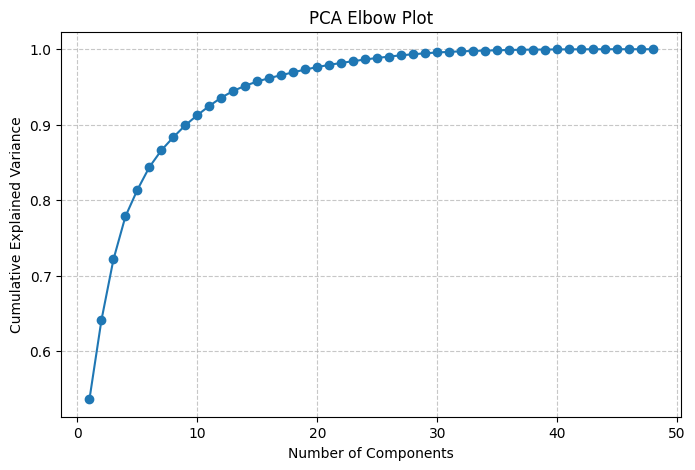

In [ ]:
ft.fillna_zero()
ft.fit_pca()
ft.plot_elbow()

In [ ]:
train_pca, test_pca = ft.transform(n_features=20) #20
#train_pca = train_scaled
#test_pca = test_scaled

print("\nPCA Train:")
display(train_pca.head())
print("\nPCA Test:")
display(test_pca.head())


PCA Train:


,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,PCA_11,PCA_12,PCA_13,PCA_14,PCA_15,PCA_16,PCA_17,PCA_18,PCA_19,PCA_20
Date,,,,,,,,,,,,,,,,,,,,
2018-06-25 00:00:00+00:00,-0.470217,-0.580725,-0.517725,0.150628,0.266650,0.247067,-0.264435,0.172475,-0.350575,-0.093696,0.017259,-0.017657,-0.237705,0.150472,0.046347,0.017939,0.009403,-0.039386,0.049044,-0.074185
2018-06-26 00:00:00+00:00,-1.046613,-0.090578,-0.563681,0.148712,-0.063667,-0.030977,-0.327085,0.284316,-0.293694,0.014750,-0.020818,0.035455,-0.226303,-0.020702,-0.035067,0.061286,0.110110,-0.194479,-0.038225,-0.044475
2018-06-27 00:00:00+00:00,-1.088018,-0.623484,-0.422154,0.274551,-0.067669,0.028684,-0.152058,0.126871,-0.275312,0.038780,0.064311,-0.062628,-0.190273,0.033543,0.174879,0.013094,-0.196005,-0.175997,0.063877,0.006433
2018-06-28 00:00:00+00:00,-1.415699,0.166265,-0.566063,0.236935,-0.020372,-0.144940,-0.284817,0.249374,-0.171946,0.060877,0.081610,0.007848,-0.156581,0.014181,0.219280,-0.123094,-0.324433,-0.058005,0.035112,-0.036351
2018-06-29 00:00:00+00:00,-1.271941,-0.394961,-0.355352,0.356353,0.069803,-0.029299,-0.009814,-0.104742,-0.189683,0.027963,0.046279,-0.096506,-0.132887,0.025826,0.143632,0.018015,0.012211,-0.066201,0.059558,0.031740



PCA Test:


,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,PCA_11,PCA_12,PCA_13,PCA_14,PCA_15,PCA_16,PCA_17,PCA_18,PCA_19,PCA_20
Date,,,,,,,,,,,,,,,,,,,,
2025-01-02 00:00:00+00:00,-0.886819,0.382056,-0.277622,-0.279190,-0.405490,-0.296418,0.114174,0.053665,0.089382,0.219717,0.282043,-0.030422,0.130711,-0.042651,0.267884,0.061476,0.169786,0.053753,-0.042038,0.117105
2025-01-03 00:00:00+00:00,-1.068207,-0.489951,-0.178212,-0.364331,-0.140707,-0.231612,0.238473,-0.038318,0.124988,0.146193,0.328123,-0.014194,0.065304,-0.145166,-0.008548,0.131999,-0.010769,-0.008136,-0.072836,0.014999
2025-01-06 00:00:00+00:00,-0.734465,0.436752,-0.213659,0.075911,-0.302436,-0.112767,0.272960,-0.027357,0.061982,0.270883,0.131864,-0.223412,-0.089191,-0.042671,0.012325,0.101426,-0.002666,-0.073882,-0.016727,-0.011507
2025-01-07 00:00:00+00:00,-0.525808,-0.166239,0.023546,0.206209,-0.158382,-0.073945,0.286332,-0.062083,0.098638,0.273288,0.217695,-0.136978,-0.095617,-0.032553,0.009954,0.108989,0.008634,-0.125697,-0.033821,-0.057012
2025-01-08 00:00:00+00:00,-0.775135,-0.334282,0.044151,-0.061636,0.027603,-0.146402,0.179255,-0.120821,0.163809,0.260176,0.198540,-0.118122,-0.074903,-0.055351,0.007370,0.010784,0.025166,-0.075771,0.069804,-0.031176


# Estimate Cluster Model

In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def Cluster_and_score(train_data, test_data, model, model_name, df_estimate_train, df_estimate_test):

    # Fit model
    train_labels = model.fit_predict(train_data)

    # Handle test labels for models without a predict method
    if hasattr(model, 'predict'):
        test_labels = model.predict(test_data)
    else:
        # Use Nearest Neighbors with k=3 for DBSCAN test labeling
        nn = NearestNeighbors(n_neighbors=3).fit(train_data[train_labels != -1])  # fit on non-noise points
        _, indices = nn.kneighbors(test_data)

        # Map nearest neighbors’ labels
        neighbor_labels = train_labels[train_labels != -1][indices]

        # Assign most common label among the 3 nearest neighbors
        test_labels = np.array([np.bincount(row).argmax() for row in neighbor_labels])


    # Add labels
    df_estimate_train[f'Cluster_{model_name}'] = train_labels
    df_estimate_test[f'Cluster_{model_name}'] = test_labels

    return df_estimate_train, df_estimate_test

In [ ]:
pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 12.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=2176936 sha256=0e822fccfbd8c67a3a877674351bfdbcd99118b34c7774a7d66ab0037a175721
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra


In [ ]:
from sklearn.cluster import (
    KMeans, AgglomerativeClustering, DBSCAN, OPTICS,
    MeanShift, SpectralClustering, AffinityPropagation, Birch
)
from sklearn.mixture import BayesianGaussianMixture
#from sklearn_extra.cluster import KMedoids


In [ ]:
train_pca

,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,PCA_11,PCA_12,PCA_13,PCA_14,PCA_15,PCA_16,PCA_17,PCA_18,PCA_19,PCA_20
Date,,,,,,,,,,,,,,,,,,,,
2018-06-25 00:00:00+00:00,-0.470217,-0.580725,-0.517725,0.150628,0.266650,0.247067,-0.264435,0.172475,-0.350575,-0.093696,0.017259,-0.017657,-0.237705,0.150472,0.046347,0.017939,0.009403,-0.039386,0.049044,-0.074185
2018-06-26 00:00:00+00:00,-1.046613,-0.090578,-0.563681,0.148712,-0.063667,-0.030977,-0.327085,0.284316,-0.293694,0.014750,-0.020818,0.035455,-0.226303,-0.020702,-0.035067,0.061286,0.110110,-0.194479,-0.038225,-0.044475
2018-06-27 00:00:00+00:00,-1.088018,-0.623484,-0.422154,0.274551,-0.067669,0.028684,-0.152058,0.126871,-0.275312,0.038780,0.064311,-0.062628,-0.190273,0.033543,0.174879,0.013094,-0.196005,-0.175997,0.063877,0.006433
2018-06-28 00:00:00+00:00,-1.415699,0.166265,-0.566063,0.236935,-0.020372,-0.144940,-0.284817,0.249374,-0.171946,0.060877,0.081610,0.007848,-0.156581,0.014181,0.219280,-0.123094,-0.324433,-0.058005,0.035112,-0.036351
2018-06-29 00:00:00+00:00,-1.271941,-0.394961,-0.355352,0.356353,0.069803,-0.029299,-0.009814,-0.104742,-0.189683,0.027963,0.046279,-0.096506,-0.132887,0.025826,0.143632,0.018015,0.012211,-0.066201,0.059558,0.031740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24 00:00:00+00:00,-0.569328,-0.402959,-0.210807,0.167293,-0.722809,-0.088241,0.166575,0.211894,0.105421,0.268034,0.096070,-0.219616,0.110537,-0.029235,0.113889,0.217023,-0.049891,-0.000375,-0.001050,-0.150368
2024-12-26 00:00:00+00:00,-0.212398,-0.603827,0.045581,0.471356,-0.565135,-0.156583,-0.034522,0.572011,0.289630,0.284251,0.088824,-0.062814,0.152434,-0.136658,0.056410,0.166451,-0.119080,0.063234,-0.024712,-0.273259
2024-12-27 00:00:00+00:00,-0.024496,-0.366024,0.118667,0.450841,-0.624107,-0.101981,0.059381,0.276421,0.194581,0.227637,0.179839,0.026331,0.153664,-0.114805,0.135930,0.049011,-0.023070,0.006623,0.003294,-0.226027


In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS, MeanShift, SpectralClustering


df_estimate_train = pd.DataFrame()
df_estimate_test = pd.DataFrame()

df_estimate_train.index = train_pca.index
df_estimate_test.index = test_pca.index

cluster_list = [3, 5, 7, 9, 12]
#cluster_list = [3, 5, 7, 9, 12,20,30,40,50,100]
#cluster_list = [3, 4, 5,6, 7,8, 9, 10,11,12]

#cluster_list = [2,3]


# --------------------
# KMeans  -- LOW PERFORMANCE
# --------------------

for n_clusters in cluster_list:
    mod_name = f'KM{n_clusters}'
    model = KMeans(n_clusters=n_clusters, random_state=42)
    df_estimate_train, df_estimate_test = Cluster_and_score(
        train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
    )
    print(f"[DONE] {mod_name}")


# --------------------
# Agglomerative Clustering  -- LOW PERFORMANCE
# --------------------
#for n_clusters in cluster_list:
#    mod_name = f'AGG{n_clusters}'
#    model = AgglomerativeClustering(n_clusters=n_clusters)
#    df_estimate_train, df_estimate_test = Cluster_and_score(
#        train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
#    )

# --------------------
# Spectral Clustering
# --------------------
for n_clusters in cluster_list:
    mod_name = f'SP{n_clusters}'
    model = SpectralClustering(n_clusters=n_clusters, random_state=42, assign_labels='kmeans')
    df_estimate_train, df_estimate_test = Cluster_and_score(
        train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test

    )
    print(f"[DONE] {mod_name}")



# --------------------
# DBSCAN (only one run)
# --------------------
mod_name = 'DBSCAN'
model = DBSCAN(eps=0.5, min_samples=5)
df_estimate_train, df_estimate_test = Cluster_and_score(
    train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
)
print(f"[DONE] {mod_name}")


# --------------------
# OPTICS (only one run)
# --------------------
mod_name = 'OPTICS-005'
model = OPTICS(min_samples=3, xi=0.05, min_cluster_size=0.05)
df_estimate_train, df_estimate_test = Cluster_and_score(
    train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
)
print(f"[DONE] {mod_name}")

mod_name = 'OPTICS-010'
model = OPTICS(min_samples=5, xi=0.10, min_cluster_size=0.10)
df_estimate_train, df_estimate_test = Cluster_and_score(
    train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
)
print(f"[DONE] {mod_name}")

# --------------------
# MeanShift (only one run)
# --------------------
#mod_name = 'MeanShift'
#model = MeanShift()
#df_estimate_train, df_estimate_test = Cluster_and_score(
#    train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
#)
#print(f"[DONE] {mod_name}")



# --------------------
# Bayesian Gaussian Mixture
# --------------------
mod_name = "BayesGMM"
model = BayesianGaussianMixture(n_components=5, random_state=42)  # upper bound on clusters
df_estimate_train, df_estimate_test = Cluster_and_score(
    train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
)
print(f"[DONE] {mod_name}")

# --------------------
# Affinity Propagation
# --------------------
mod_name = "AffinityProp-50"
model = AffinityPropagation(random_state=42,
                            preference=-50)
df_estimate_train, df_estimate_test = Cluster_and_score(
    train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
)
print(f"[DONE] {mod_name}")

mod_name = "AffinityProp"
model = AffinityPropagation(random_state=42,
                            preference=-10)
df_estimate_train, df_estimate_test = Cluster_and_score(
    train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
)
print(f"[DONE] {mod_name}")

# --------------------
# Birch
# --------------------
for n_clusters in cluster_list:
    mod_name = f'Birch{n_clusters}'
    model = Birch(n_clusters=n_clusters)
    df_estimate_train, df_estimate_test = Cluster_and_score(
        train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
    )
print(f"[DONE] {mod_name}")

[DONE] KM3
[DONE] KM5
[DONE] KM7
[DONE] KM9
[DONE] KM12
[DONE] SP3
[DONE] SP5
[DONE] SP7
[DONE] SP9
[DONE] SP12
[DONE] DBSCAN
[DONE] OPTICS-005
[DONE] OPTICS-010
[DONE] BayesGMM
[DONE] AffinityProp-50
[DONE] AffinityProp
[DONE] Birch12


In [ ]:
df_estimate_train

,Cluster_KM3,Cluster_KM5,Cluster_KM7,Cluster_KM9,Cluster_KM12,Cluster_SP3,Cluster_SP5,Cluster_SP7,Cluster_SP9,Cluster_SP12,...,Cluster_OPTICS-005,Cluster_OPTICS-010,Cluster_BayesGMM,Cluster_AffinityProp-50,Cluster_AffinityProp,Cluster_Birch3,Cluster_Birch5,Cluster_Birch7,Cluster_Birch9,Cluster_Birch12
Date,,,,,,,,,,,,,,,,,,,,,
2018-06-25 00:00:00+00:00,2,2,5,8,5,0,0,2,6,0,...,0,0,2,1,2,0,3,1,1,1
2018-06-26 00:00:00+00:00,1,3,3,5,5,0,3,0,6,10,...,0,0,3,5,16,0,3,1,1,1
2018-06-27 00:00:00+00:00,1,3,3,2,5,0,3,0,0,0,...,0,0,3,5,16,0,3,1,1,1
2018-06-28 00:00:00+00:00,1,1,3,1,1,0,3,0,3,10,...,0,0,3,5,16,0,3,1,1,1
2018-06-29 00:00:00+00:00,1,3,3,2,2,0,3,0,0,0,...,0,0,3,5,16,0,3,1,1,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24 00:00:00+00:00,2,3,3,5,5,0,0,2,0,0,...,0,0,3,5,9,0,1,0,0,5
2024-12-26 00:00:00+00:00,2,2,5,7,11,0,0,2,6,5,...,0,0,4,1,9,1,0,2,2,10
2024-12-27 00:00:00+00:00,2,4,5,4,11,0,0,2,6,5,...,0,0,4,1,10,1,0,2,2,10


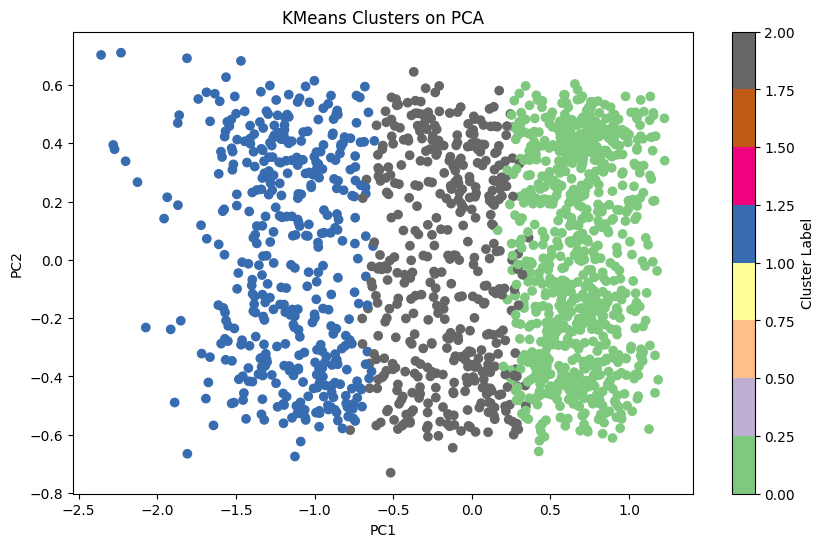

In [ ]:
# Visualize
plt.figure(figsize=(10, 6)) # Added figure size for better visualization
plt.scatter(train_pca['PCA_1'], train_pca['PCA_2'], c=df_estimate_train['Cluster_KM3'], cmap='Accent') # Access columns by name
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters on PCA")
plt.colorbar(label='Cluster Label') # Added colorbar for clarity
plt.show()

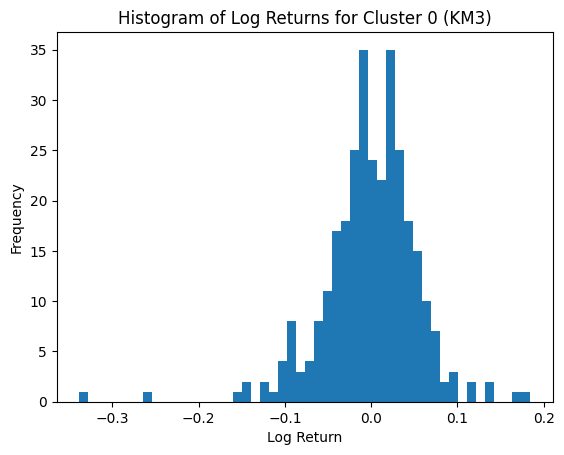

In [ ]:
df_clust_hist = df_estimate_train.copy()
df_clust_hist['Log_ret'] = df_log_ret_train_backtest.values

df_clust_hist = df_clust_hist[df_clust_hist['Cluster_SP5']==3]

df_clust_hist['Log_ret'].plot.hist(bins=50) # Use plot.hist() for histogram
plt.title('Histogram of Log Returns for Cluster 0 (KM3)') # Added title
plt.xlabel('Log Return') # Added xlabel
plt.ylabel('Frequency') # Added ylabel
plt.show() # Show the plot

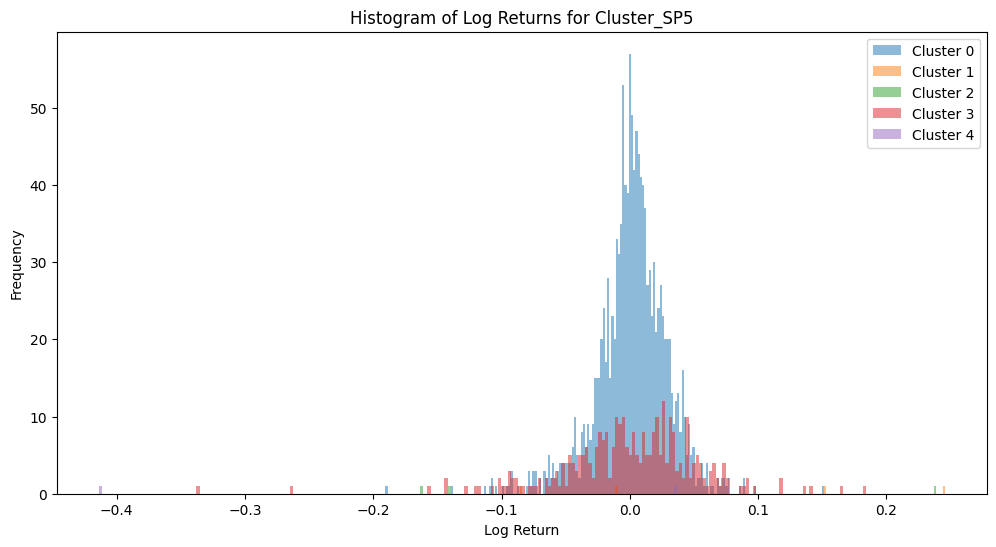

In [ ]:
import matplotlib.pyplot as plt

# Copy and add log returns
df_clust_hist = df_estimate_train.copy()
df_clust_hist['Log_ret'] = df_log_ret_train_backtest.values

# Select the cluster column you want to analyze
cluster_col = 'Cluster_SP5'

plt.figure(figsize=(12,6))

# Loop over all unique clusters
for cluster in sorted(df_clust_hist[cluster_col].unique()):
    subset = df_clust_hist[df_clust_hist[cluster_col] == cluster]
    plt.hist(subset['Log_ret'], bins=200, alpha=0.5, label=f"Cluster {cluster}")

plt.title(f"Histogram of Log Returns for {cluster_col}")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()


/tmp/ipython-input-3019791608.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(clusters))


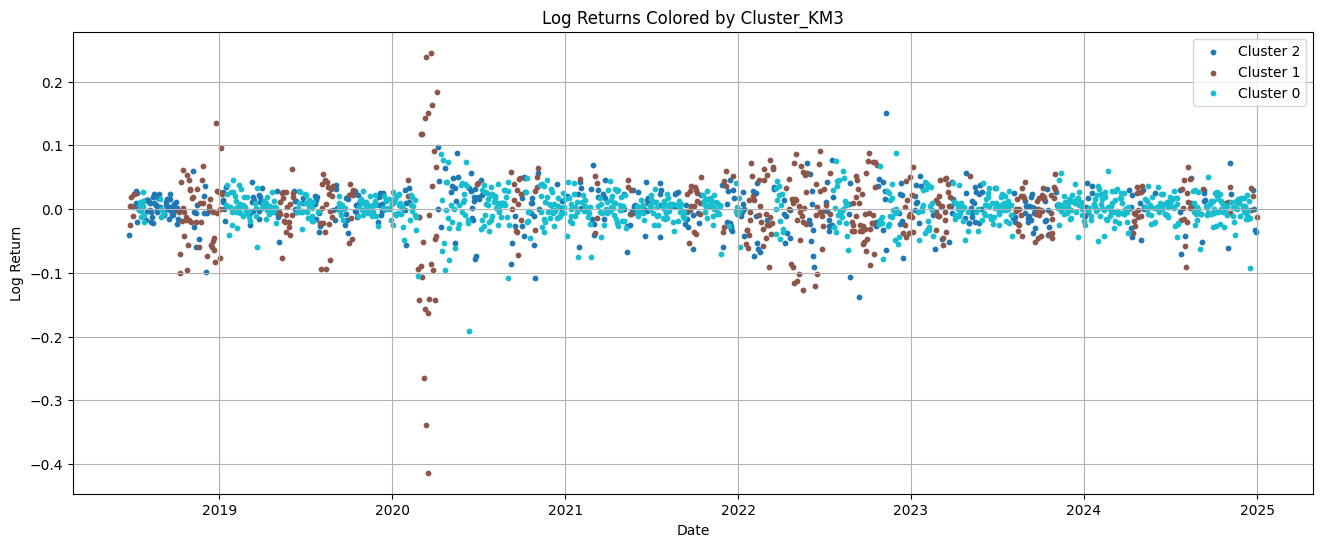

In [ ]:
import matplotlib.pyplot as plt

# Prepare
df_clust_hist = df_estimate_train.copy()
df_clust_hist['Log_ret'] = df_log_ret_train_backtest.values

plt.figure(figsize=(16, 6))

# Select cluster columns
cluster_cols = [col for col in df_estimate_train.columns if 'Cluster' in col]

# Choose one cluster labeling to plot (e.g., KM5)
cluster_label_col = cluster_cols[0]  # or set manually: 'Cluster_KM5'
clusters = df_clust_hist[cluster_label_col].unique()

# Map clusters to colors
colors = plt.cm.get_cmap('tab10', len(clusters))

for i, cluster in enumerate(clusters):
    cluster_data = df_clust_hist[df_clust_hist[cluster_label_col] == cluster]
    plt.scatter(cluster_data.index, cluster_data['Log_ret'], color=colors(i), label=f'Cluster {cluster}', s=10)

plt.title(f'Log Returns Colored by {cluster_label_col}')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-3829386050.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(clusters))


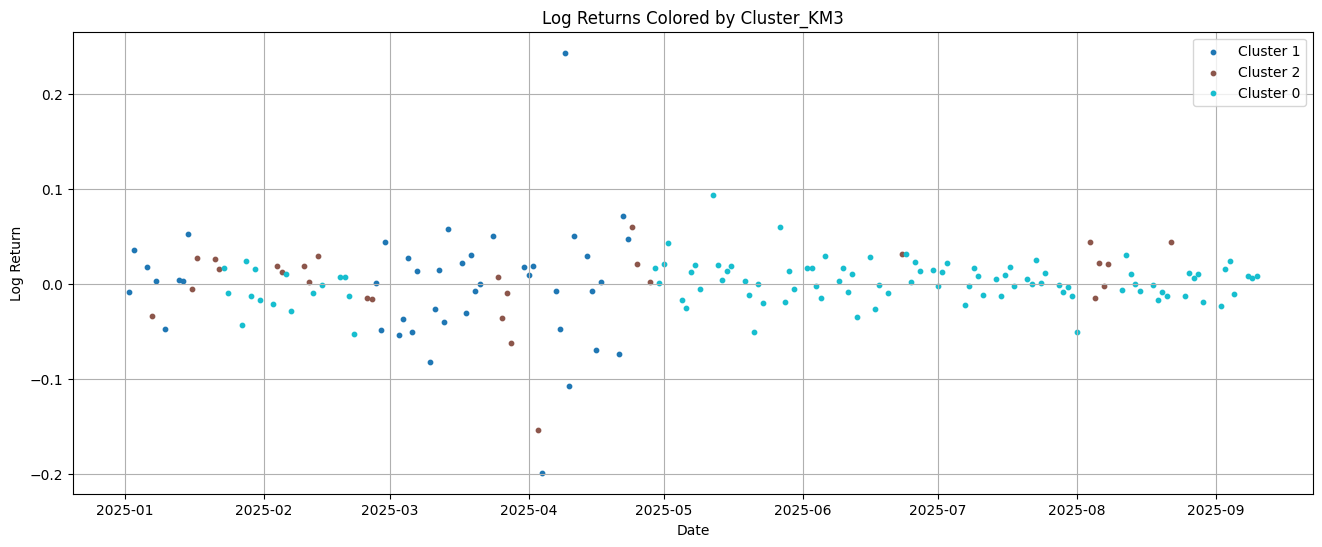

In [ ]:
import matplotlib.pyplot as plt

# Prepare
df_clust_hist = df_estimate_test.copy()
df_clust_hist['Log_ret'] = df_log_ret_test_backtest.values

plt.figure(figsize=(16, 6))

# Select cluster columns
cluster_cols = [col for col in df_estimate_test.columns if 'Cluster' in col]

# Choose one cluster labeling to plot (e.g., KM5)
cluster_label_col = cluster_cols[0]  # or set manually: 'Cluster_KM5'
clusters = df_clust_hist[cluster_label_col].unique()

# Map clusters to colors
colors = plt.cm.get_cmap('tab10', len(clusters))

for i, cluster in enumerate(clusters):
    cluster_data = df_clust_hist[df_clust_hist[cluster_label_col] == cluster]
    plt.scatter(cluster_data.index, cluster_data['Log_ret'], color=colors(i), label=f'Cluster {cluster}', s=10)

plt.title(f'Log Returns Colored by {cluster_label_col}')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-972530006.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(clusters))


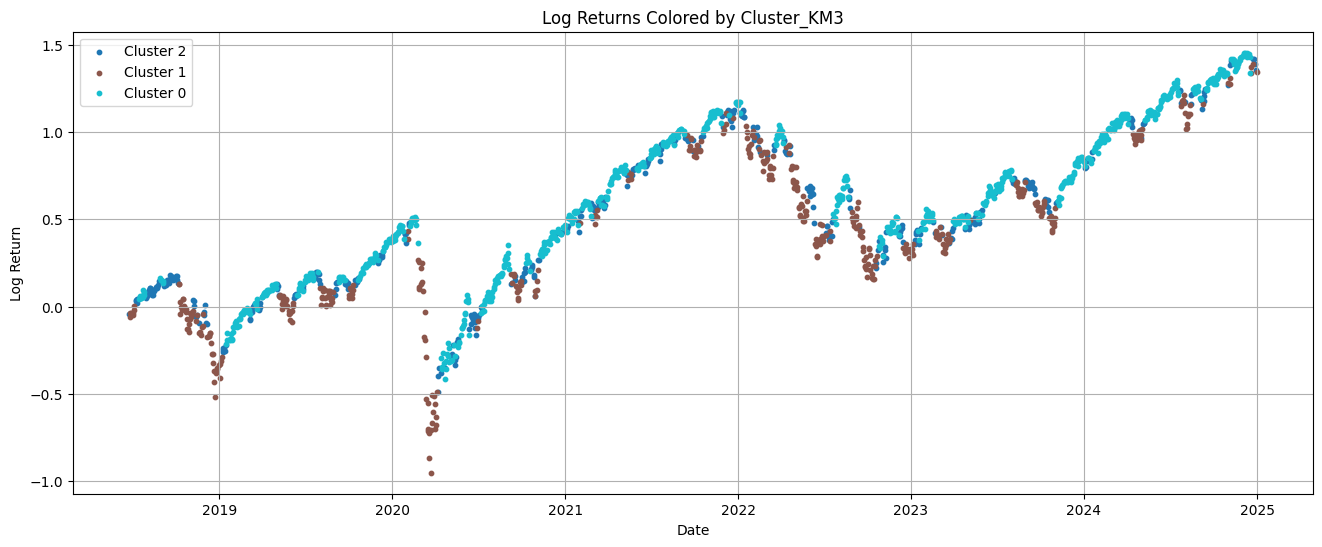

In [ ]:
# Prepare
df_clust_hist = df_estimate_train.copy()
df_clust_hist['Log_ret'] = df_log_ret_train_backtest.values
df_clust_hist['Log_ret'] = df_clust_hist['Log_ret'].cumsum()

plt.figure(figsize=(16, 6))

# Select cluster columns
cluster_cols = [col for col in df_estimate_train.columns if 'Cluster' in col]

# Choose one cluster labeling to plot (e.g., KM5)
cluster_label_col = cluster_cols[0]  # or set manually: 'Cluster_KM5'
clusters = df_clust_hist[cluster_label_col].unique()

# Map clusters to colors
colors = plt.cm.get_cmap('tab10', len(clusters))

for i, cluster in enumerate(clusters):
    cluster_data = df_clust_hist[df_clust_hist[cluster_label_col] == cluster]
    plt.scatter(cluster_data.index, cluster_data['Log_ret'], color=colors(i), label=f'Cluster {cluster}', s=10)

plt.title(f'Log Returns Colored by {cluster_label_col}')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.show()


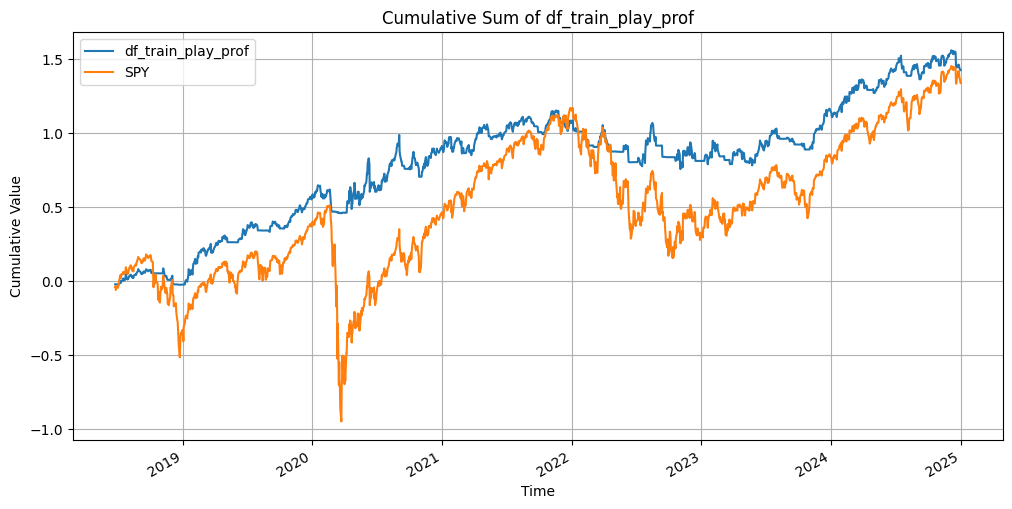

In [ ]:
df_train_play = df_estimate_train['Cluster_KM3'].copy()
df_train_play.replace(2, 0.55, inplace=True)
df_train_play.replace(1, 0.01, inplace=True)
df_train_play.replace(0, 0.99, inplace=True)

df_train_play_prof = df_train_play*df_log_ret_train_backtest[ticker_top[0]]


import matplotlib.pyplot as plt

# Compute cumulative sum
cum_sum = df_train_play_prof.cumsum()

# Plot
plt.figure(figsize=(12,6))
cum_sum.plot()
(df_log_ret_train_backtest[ticker_top[0]].cumsum()*1).plot()
plt.title("Cumulative Sum of df_train_play_prof")
plt.xlabel("Time")
plt.ylabel("Cumulative Value")
plt.grid(True)
plt.legend(['df_train_play_prof', 'SPY'])
plt.show()


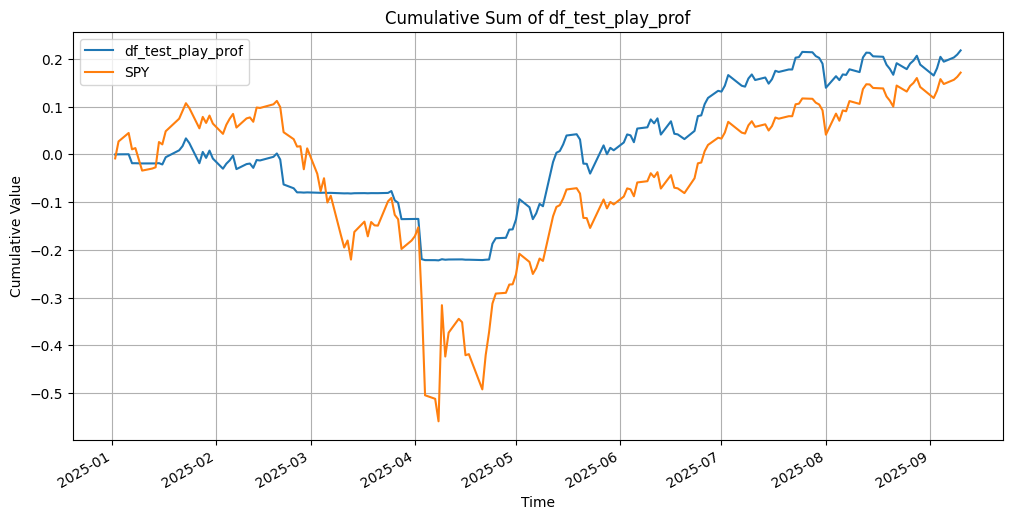

In [ ]:
df_test_play = df_estimate_test['Cluster_KM3'].copy()
df_test_play.replace(2, 0.55, inplace=True)
df_test_play.replace(1, 0.01, inplace=True)
df_test_play.replace(0, 0.99, inplace=True)

df_test_play_prof = df_test_play*df_log_ret_test_backtest[ticker_top[0]]


import matplotlib.pyplot as plt

# Compute cumulative sum
cum_sum = df_test_play_prof.cumsum()

# Plot
plt.figure(figsize=(12,6))
cum_sum.plot()
df_log_ret_test_backtest[ticker_top[0]].cumsum().plot()
plt.title("Cumulative Sum of df_test_play_prof")
plt.xlabel("Time")
plt.ylabel("Cumulative Value")
plt.grid(True)
plt.legend(['df_test_play_prof', 'SPY'])
plt.show()


/tmp/ipython-input-346655663.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(clusters))


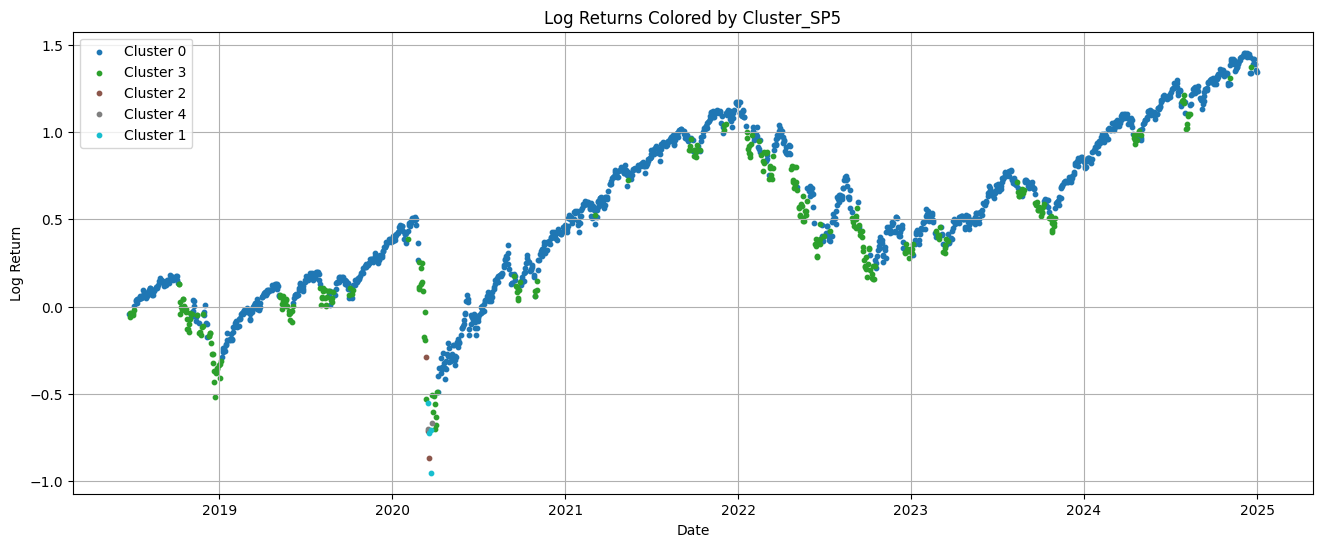

In [ ]:
# Prepare
df_clust_hist = df_estimate_train.copy()
df_clust_hist['Log_ret'] = df_log_ret_train_backtest.values
df_clust_hist['Log_ret'] = df_clust_hist['Log_ret'].cumsum()

plt.figure(figsize=(16, 6))

# Select cluster columns
cluster_cols = [col for col in df_estimate_train.columns if 'Cluster' in col]

# Choose one cluster labeling to plot (e.g., KM5)
cluster_label_col = cluster_cols[6]  # or set manually: 'Cluster_KM5'
clusters = df_clust_hist[cluster_label_col].unique()

# Map clusters to colors
colors = plt.cm.get_cmap('tab10', len(clusters))

for i, cluster in enumerate(clusters):
    cluster_data = df_clust_hist[df_clust_hist[cluster_label_col] == cluster]
    plt.scatter(cluster_data.index, cluster_data['Log_ret'], color=colors(i), label=f'Cluster {cluster}', s=10)

plt.title(f'Log Returns Colored by {cluster_label_col}')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.show()


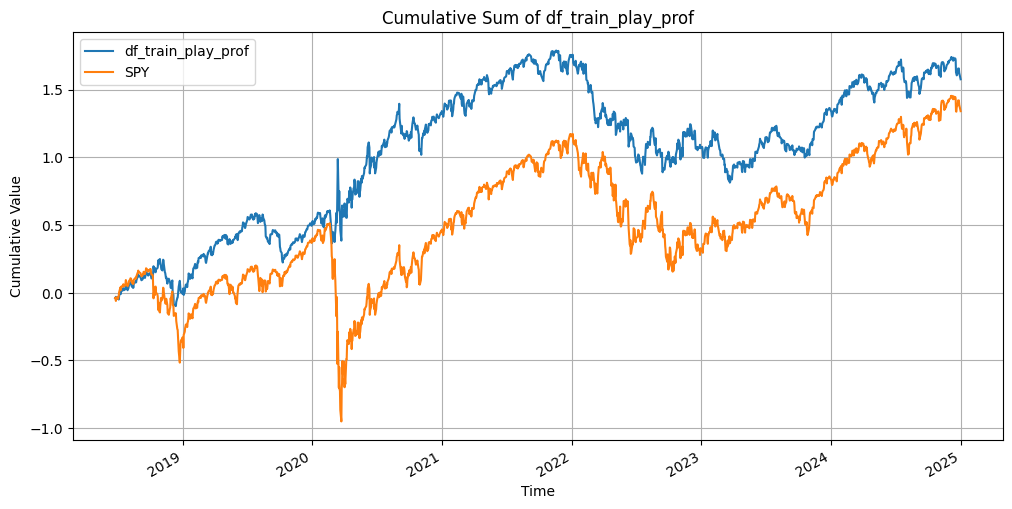

In [ ]:
df_train_play = df_estimate_train['Cluster_SP5'].copy()
df_train_play.replace(4, .91, inplace=True)
df_train_play.replace(3, -.51, inplace=True)
df_train_play.replace(2, .91, inplace=True)
df_train_play.replace(1, .92, inplace=True)
df_train_play.replace(0, 1, inplace=True)

df_train_play_prof = df_train_play*df_log_ret_train_backtest[ticker_top[0]]


import matplotlib.pyplot as plt

# Compute cumulative sum
cum_sum = df_train_play_prof.cumsum()

# Plot
plt.figure(figsize=(12,6))
cum_sum.plot()
(df_log_ret_train_backtest[ticker_top[0]].cumsum()*1).plot()
plt.title("Cumulative Sum of df_train_play_prof")
plt.xlabel("Time")
plt.ylabel("Cumulative Value")
plt.grid(True)
plt.legend(['df_train_play_prof', 'SPY'])
plt.show()


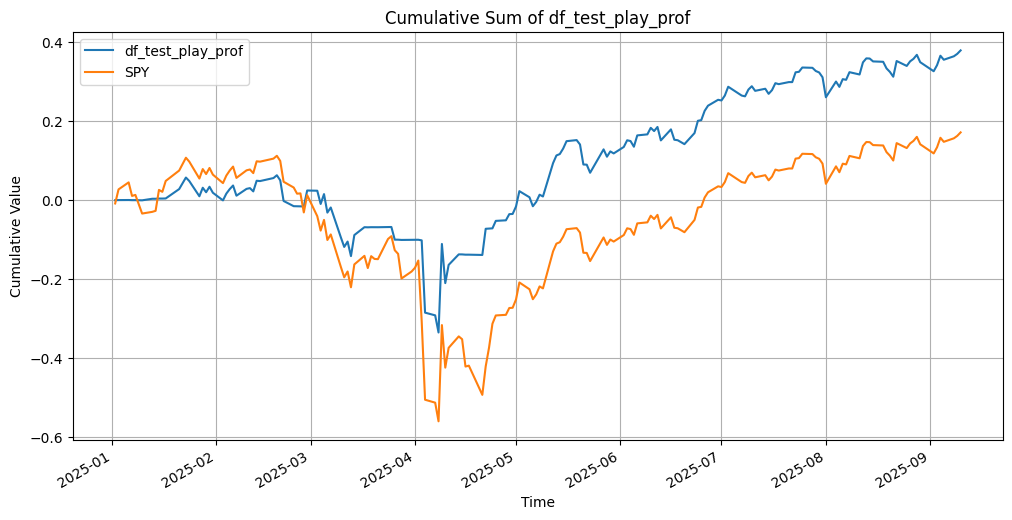

In [ ]:
df_test_play = df_estimate_test['Cluster_KM5'].copy()
df_test_play.replace(4, .901, inplace=True)
df_test_play.replace(3, .01, inplace=True)
df_test_play.replace(2, .901, inplace=True)
df_test_play.replace(1, 0.92, inplace=True)
df_test_play.replace(0, 0.991, inplace=True)

df_test_play_prof = df_test_play*df_log_ret_test_backtest[ticker_top[0]]


import matplotlib.pyplot as plt

# Compute cumulative sum
cum_sum = df_test_play_prof.cumsum()

# Plot
plt.figure(figsize=(12,6))
cum_sum.plot()
df_log_ret_test_backtest[ticker_top[0]].cumsum().plot()
plt.title("Cumulative Sum of df_test_play_prof")
plt.xlabel("Time")
plt.ylabel("Cumulative Value")
plt.grid(True)
plt.legend(['df_test_play_prof', 'SPY'])
plt.show()


/tmp/ipython-input-4217374362.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(clusters))


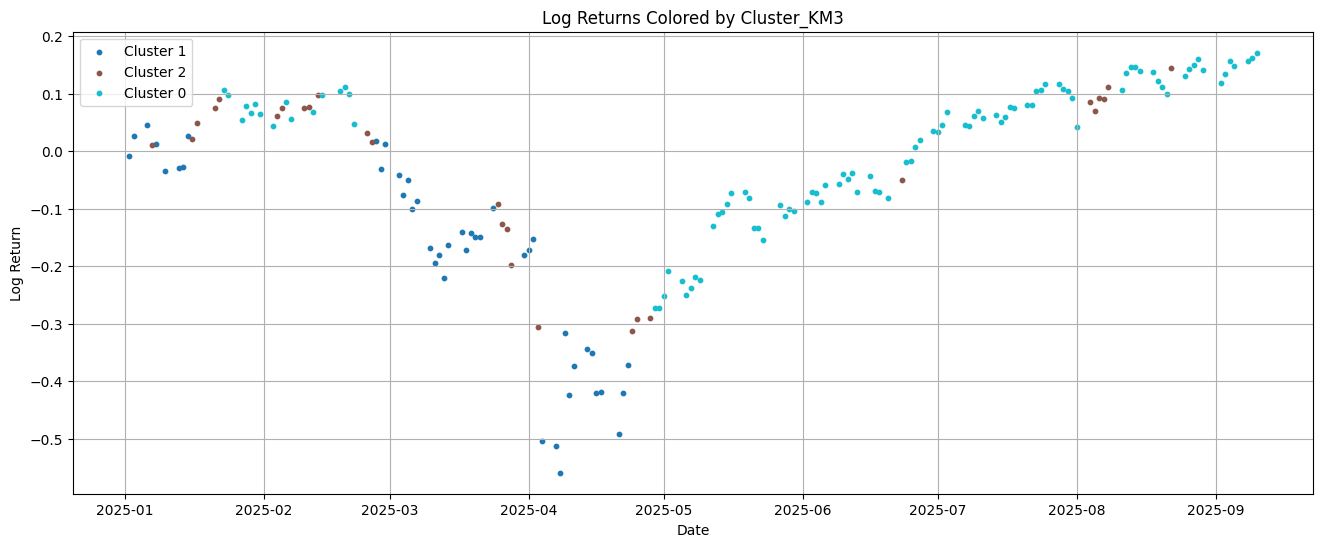

In [ ]:
# Prepare
df_clust_hist = df_estimate_test.copy()
df_clust_hist['Log_ret'] = df_log_ret_test_backtest.values
df_clust_hist['Log_ret'] = df_clust_hist['Log_ret'].cumsum()

plt.figure(figsize=(16, 6))

# Select cluster columns
cluster_cols = [col for col in df_estimate_test.columns if 'Cluster' in col]

# Choose one cluster labeling to plot (e.g., KM5)
cluster_label_col = cluster_cols[0]  # or set manually: 'Cluster_KM5'
clusters = df_clust_hist[cluster_label_col].unique()

# Map clusters to colors
colors = plt.cm.get_cmap('tab10', len(clusters))

for i, cluster in enumerate(clusters):
    cluster_data = df_clust_hist[df_clust_hist[cluster_label_col] == cluster]
    plt.scatter(cluster_data.index, cluster_data['Log_ret'], color=colors(i), label=f'Cluster {cluster}', s=10)

plt.title(f'Log Returns Colored by {cluster_label_col}')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.show()


# Weights assign logic

In [ ]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd

def backtest_optimal_cluster_weights_df(log_returns_train, cluster_train, cluster_test=None):
    """
    Compute optimal weights per cluster on training data and backtest.
    Optionally apply the same weights to test cluster labels.

    Args:
        log_returns_train (pd.Series or pd.DataFrame): Asset log returns (train).
        cluster_train (pd.Series): Cluster assignment for train data.
        cluster_test (pd.Series or None): Cluster assignment for test data.

    Returns:
        weight_series_train (pd.Series): Cluster weights aligned with train index.
        weight_series_test (pd.Series or None): Cluster weights aligned with test index if provided.
    """

    unique_clusters = cluster_train.unique()
    n_clusters = len(unique_clusters)

    # Objective: maximize cumulative portfolio return
    def objective(weights):
        weighted = np.zeros(len(log_returns_train))
        for w, c in zip(weights, unique_clusters):
            weighted += (cluster_train.values == c) * w * log_returns_train.values.flatten()
        return -np.sum(weighted)


    # Objective: maximize Sharpe ratio
    def objective(weights):
        # portfolio returns
        weighted = np.zeros(len(log_returns_train))
        for w, c in zip(weights, unique_clusters):
            weighted += (cluster_train.values == c) * w * log_returns_train.values.flatten()

        portfolio_return = np.mean(weighted)
        portfolio_vol = np.std(weighted)

        # if vol = 0, return large penalty
        if portfolio_vol == 0:
            return 1e6

        # we NEGATE because scipy minimize()
        return -portfolio_return / portfolio_vol



    # Initial guess: equal weights
    x0 = np.ones(n_clusters) / n_clusters

    # Bounds: weights between 0 and 1
    bounds = [(-1, 1) for _ in range(n_clusters)]

    # Constraint: sum(weights) <= 1 # DANGER
    constraints = {"type": "ineq", "fun": lambda w: 1 - np.sum(w)}

    res = minimize(objective, x0, bounds=bounds, constraints=constraints, method='SLSQP')
    opt_weights = res.x

    # Map weights using lambda instead of map
    weight_dict = dict(zip(unique_clusters, opt_weights))
    weight_series_train = cluster_train.apply(lambda x: weight_dict[x])

    weight_series_test = None
    if cluster_test is not None:
        weight_series_test = cluster_test.apply(lambda x: weight_dict[x])





    return weight_series_train, weight_series_test


In [ ]:
# -------------------- Function to compute portfolio returns & equity --------------------
def compute_portfolio(df_log_ret, df_weights, col_prefix):
    """
    Compute portfolio returns and equity curve.

    Args:
        df_log_ret (DataFrame): Log returns of assets/clusters
        df_weights (DataFrame): Portfolio weights (same shape as df_log_ret)
        col_prefix (str): Prefix for columns in output DataFrame

    Returns:
        DataFrame: Portfolio returns and equity curve
    """
    # Ensure shapes match
    assert df_weights.shape == df_log_ret.shape, "Shapes must match!"

    # Element-wise multiplication
    portfolio_returns = df_weights.to_numpy() * df_log_ret.to_numpy()

    # Build DataFrame with original index and columns
    df_portfolio = pd.DataFrame(
        portfolio_returns,
        index=df_log_ret.index,
        columns=df_log_ret.columns
    )

    # Compute total portfolio return (sum across columns) and equity curve
    df_portfolio[f'{col_prefix}_returns'] = df_portfolio.sum(axis=1)
    df_portfolio[f'{col_prefix}_equity_curve'] = df_portfolio[f'{col_prefix}_returns'].cumsum()

    return df_portfolio[[f'{col_prefix}_returns', f'{col_prefix}_equity_curve']]

In [ ]:
cluster_cols = [col for col in df_estimate_train.columns]

len_clusters =  len(cluster_cols)
# Dictionaries to store results
df_portfolios_train = pd.DataFrame()
df_portfolios_test = pd.DataFrame()

for col in cluster_cols:
    print(f"Processing {col}...")

    # Compute optimal cluster weights
    weight_series_train, weight_series_test = backtest_optimal_cluster_weights_df(
        df_log_ret_train_backtest,
        df_estimate_train[col],
        cluster_test=df_estimate_test[col]
    )

    # -------------------- Train --------------------
    df_res_train = pd.DataFrame()
    # Corrected to use 'ADA-USD' column
    df_res_train['Portfolio_returns'] = df_log_ret_train_backtest[ticker_top[0]] * weight_series_train
    df_res_train['Equity_curve'] = df_res_train['Portfolio_returns'].cumsum()

    df_portfolios_train[f'{col}_returns'] = df_res_train['Portfolio_returns']
    df_portfolios_train[f'{col}_equity_curve'] = df_res_train['Equity_curve']

    # -------------------- Test --------------------
    df_res_test = pd.DataFrame()
    # Corrected to use 'ADA-USD' column
    df_res_test['Portfolio_returns'] = df_log_ret_test_backtest[ticker_top[0]] * weight_series_test
    df_res_test['Equity_curve'] = df_res_test['Portfolio_returns'].cumsum()

    df_portfolios_test[f'{col}_returns'] = df_res_test['Portfolio_returns']
    df_portfolios_test[f'{col}_equity_curve'] = df_res_test['Equity_curve']


# TRAIN
return_cols_train = [col for col in df_portfolios_train.columns if 'returns' in col and 'Portfolio' not in col]
df_portfolios_train['Portfolio_returns'] = df_portfolios_train[return_cols_train].sum(axis=1) / len(return_cols_train)
df_portfolios_train['Portfolio_returns'] = df_portfolios_train['Portfolio_returns'] * 2

df_portfolios_train['Portfolio_equity_curve'] = df_portfolios_train['Portfolio_returns'].cumsum()

# TEST
return_cols_test = [col for col in df_portfolios_test.columns if 'returns' in col and 'Portfolio' not in col]
df_portfolios_test['Portfolio_returns'] = df_portfolios_test[return_cols_test].sum(axis=1) / len(return_cols_test)
df_portfolios_test['Portfolio_returns'] = df_portfolios_test['Portfolio_returns'] * 2

df_portfolios_test['Portfolio_equity_curve'] = df_portfolios_test['Portfolio_returns'].cumsum()

Processing Cluster_KM3...
Processing Cluster_KM5...
Processing Cluster_KM7...
Processing Cluster_KM9...
Processing Cluster_KM12...
Processing Cluster_SP3...
Processing Cluster_SP5...
Processing Cluster_SP7...
Processing Cluster_SP9...
Processing Cluster_SP12...
Processing Cluster_DBSCAN...
Processing Cluster_OPTICS-005...
Processing Cluster_OPTICS-010...
Processing Cluster_BayesGMM...
Processing Cluster_AffinityProp-50...
Processing Cluster_AffinityProp...
Processing Cluster_Birch3...
Processing Cluster_Birch5...
Processing Cluster_Birch7...
Processing Cluster_Birch9...
Processing Cluster_Birch12...


In [ ]:
df_portfolios_train

,Cluster_KM3_returns,Cluster_KM3_equity_curve,Cluster_KM5_returns,Cluster_KM5_equity_curve,Cluster_KM7_returns,Cluster_KM7_equity_curve,Cluster_KM9_returns,Cluster_KM9_equity_curve,Cluster_KM12_returns,Cluster_KM12_equity_curve,...,Cluster_Birch5_returns,Cluster_Birch5_equity_curve,Cluster_Birch7_returns,Cluster_Birch7_equity_curve,Cluster_Birch9_returns,Cluster_Birch9_equity_curve,Cluster_Birch12_returns,Cluster_Birch12_equity_curve,Portfolio_returns,Portfolio_equity_curve
Date,,,,,,,,,,,,,,,,,,,,,
2018-06-25 00:00:00+00:00,-0.014349,-0.014349,-0.008214,-0.008214,-0.008153,-0.008153,0.007383,0.007383,-0.007058,-0.007058,...,0.004341,0.004341,0.002572,0.002572,0.002891,0.002891,0.006023,0.006023,-0.007697,-0.007697
2018-06-26 00:00:00+00:00,-0.000372,-0.014722,-0.000240,-0.008453,-0.000090,-0.008243,0.000141,0.007524,0.000971,-0.006087,...,-0.000597,0.003744,-0.000354,0.002218,-0.000398,0.002494,-0.000828,0.005195,0.000229,-0.007468
2018-06-27 00:00:00+00:00,0.001700,-0.013022,0.001095,-0.007359,0.000412,-0.007832,-0.003589,0.003936,-0.004432,-0.010518,...,0.002726,0.006470,0.001615,0.003833,0.001816,0.004309,0.003782,0.008977,-0.001592,-0.009060
2018-06-28 00:00:00+00:00,-0.001238,-0.014260,-0.000228,-0.007586,-0.000300,-0.008132,-0.000976,0.002959,-0.001779,-0.012297,...,-0.001985,0.004485,-0.001176,0.002657,-0.001322,0.002987,-0.002754,0.006223,-0.000009,-0.009069
2018-06-29 00:00:00+00:00,-0.000298,-0.014558,-0.000192,-0.007779,-0.000072,-0.008204,0.000630,0.003589,0.000283,-0.012014,...,-0.000479,0.004006,-0.000284,0.002373,-0.000319,0.002668,0.000244,0.006466,0.000336,-0.008733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24 00:00:00+00:00,0.010807,0.956198,-0.001313,0.551939,-0.000494,0.486038,0.000774,0.614119,0.005316,0.524076,...,0.004668,0.842636,0.002777,0.619183,0.000783,0.510588,0.002934,0.641422,0.006633,1.206094
2024-12-26 00:00:00+00:00,0.000019,0.956218,0.000011,0.551950,0.000011,0.486049,-0.000003,0.614116,0.000011,0.524088,...,0.000019,0.842655,0.000005,0.619189,0.000004,0.510592,0.000004,0.641426,0.000024,1.206118
2024-12-27 00:00:00+00:00,-0.011264,0.944954,-0.011224,0.540726,-0.006400,0.479648,-0.004786,0.609330,-0.006643,0.517445,...,-0.011265,0.831389,-0.003123,0.616065,-0.002231,0.508361,-0.002234,0.639192,-0.015399,1.190719


In [ ]:
type(weight_series_train)

pandas.core.series.Series

In [ ]:
df_log_ret_train_backtest

Ticker,SPXL
Date,
2018-06-25 00:00:00+00:00,-0.040822
2018-06-26 00:00:00+00:00,0.005615
2018-06-27 00:00:00+00:00,-0.025634
2018-06-28 00:00:00+00:00,0.018666
2018-06-29 00:00:00+00:00,0.004501
...,...
2024-12-24 00:00:00+00:00,0.030746
2024-12-26 00:00:00+00:00,0.000055
2024-12-27 00:00:00+00:00,-0.032044


In [ ]:
df_log_ret_train_backtest * weight_series_train

,SPXL,2018-06-25 00:00:00+00:00,2018-06-26 00:00:00+00:00,2018-06-27 00:00:00+00:00,2018-06-28 00:00:00+00:00,2018-06-29 00:00:00+00:00,2018-07-02 00:00:00+00:00,2018-07-03 00:00:00+00:00,2018-07-05 00:00:00+00:00,2018-07-06 00:00:00+00:00,...,2024-12-17 00:00:00+00:00,2024-12-18 00:00:00+00:00,2024-12-19 00:00:00+00:00,2024-12-20 00:00:00+00:00,2024-12-23 00:00:00+00:00,2024-12-24 00:00:00+00:00,2024-12-26 00:00:00+00:00,2024-12-27 00:00:00+00:00,2024-12-30 00:00:00+00:00,2024-12-31 00:00:00+00:00
Date,,,,,,,,,,,,,,,,,,,,,
2018-06-25 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-26 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-28 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-06-29 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-26 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-27 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
try:
    df_log_ret_test_backtest2 = df_log_ret_test_backtest.to_frame(name=ticker_top)
    df_log_ret_train_backtest2 = df_log_ret_train_backtest.to_frame(name=ticker_top)
except:
    df_log_ret_test_backtest2 = df_log_ret_test_backtest.copy()
    df_log_ret_train_backtest2 = df_log_ret_train_backtest.copy()

df_portfolios_test['BENCH_returns'] = df_log_ret_test_backtest2[ticker_top]
df_portfolios_train['BENCH_returns'] = df_log_ret_train_backtest2[ticker_top]


# equity curve (cumulative sum of log returns)
df_portfolios_test['BENCH_equity_curve'] = df_portfolios_test['BENCH_returns'].cumsum()
df_portfolios_train['BENCH_equity_curve'] = df_portfolios_train['BENCH_returns'].cumsum()


In [ ]:
df_log_ret_test_backtest2

Ticker,SPXL
Date,
2025-01-02 00:00:00+00:00,-0.008273
2025-01-03 00:00:00+00:00,0.035580
2025-01-06 00:00:00+00:00,0.017723
2025-01-07 00:00:00+00:00,-0.034240
2025-01-08 00:00:00+00:00,0.002577
...,...
2025-09-04 00:00:00+00:00,0.024088
2025-09-05 00:00:00+00:00,-0.010245
2025-09-08 00:00:00+00:00,0.008868


## Metrices

In [ ]:
df_metrics_train = Calculate_fin_metrics(df_portfolios_train)
df_metrics_test = Calculate_fin_metrics(df_portfolios_test)

In [ ]:
df_portfolios_train

,Cluster_KM3_returns,Cluster_KM3_equity_curve,Cluster_KM5_returns,Cluster_KM5_equity_curve,Cluster_KM7_returns,Cluster_KM7_equity_curve,Cluster_KM9_returns,Cluster_KM9_equity_curve,Cluster_KM12_returns,Cluster_KM12_equity_curve,...,Cluster_Birch7_returns,Cluster_Birch7_equity_curve,Cluster_Birch9_returns,Cluster_Birch9_equity_curve,Cluster_Birch12_returns,Cluster_Birch12_equity_curve,Portfolio_returns,Portfolio_equity_curve,BENCH_returns,BENCH_equity_curve
Date,,,,,,,,,,,,,,,,,,,,,
2018-06-25 00:00:00+00:00,-0.014349,-0.014349,-0.008214,-0.008214,-0.008153,-0.008153,0.007383,0.007383,-0.007058,-0.007058,...,0.002572,0.002572,0.002891,0.002891,0.006023,0.006023,-0.007697,-0.007697,-0.040822,-0.040822
2018-06-26 00:00:00+00:00,-0.000372,-0.014722,-0.000240,-0.008453,-0.000090,-0.008243,0.000141,0.007524,0.000971,-0.006087,...,-0.000354,0.002218,-0.000398,0.002494,-0.000828,0.005195,0.000229,-0.007468,0.005615,-0.035207
2018-06-27 00:00:00+00:00,0.001700,-0.013022,0.001095,-0.007359,0.000412,-0.007832,-0.003589,0.003936,-0.004432,-0.010518,...,0.001615,0.003833,0.001816,0.004309,0.003782,0.008977,-0.001592,-0.009060,-0.025634,-0.060841
2018-06-28 00:00:00+00:00,-0.001238,-0.014260,-0.000228,-0.007586,-0.000300,-0.008132,-0.000976,0.002959,-0.001779,-0.012297,...,-0.001176,0.002657,-0.001322,0.002987,-0.002754,0.006223,-0.000009,-0.009069,0.018666,-0.042174
2018-06-29 00:00:00+00:00,-0.000298,-0.014558,-0.000192,-0.007779,-0.000072,-0.008204,0.000630,0.003589,0.000283,-0.012014,...,-0.000284,0.002373,-0.000319,0.002668,0.000244,0.006466,0.000336,-0.008733,0.004501,-0.037674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24 00:00:00+00:00,0.010807,0.956198,-0.001313,0.551939,-0.000494,0.486038,0.000774,0.614119,0.005316,0.524076,...,0.002777,0.619183,0.000783,0.510588,0.002934,0.641422,0.006633,1.206094,0.030746,1.419748
2024-12-26 00:00:00+00:00,0.000019,0.956218,0.000011,0.551950,0.000011,0.486049,-0.000003,0.614116,0.000011,0.524088,...,0.000005,0.619189,0.000004,0.510592,0.000004,0.641426,0.000024,1.206118,0.000055,1.419803
2024-12-27 00:00:00+00:00,-0.011264,0.944954,-0.011224,0.540726,-0.006400,0.479648,-0.004786,0.609330,-0.006643,0.517445,...,-0.003123,0.616065,-0.002231,0.508361,-0.002234,0.639192,-0.015399,1.190719,-0.032044,1.387759


In [ ]:
df_metrics_train_sorted = df_metrics_train.sort_values(by="Sharpe Ratio", ascending=False)  # lowest vol first

df_metrics_train_sorted

,Total Return,Annualized Return,Volatility,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown,CAGR,Skewness,Kurtosis,VaR 95%,CVaR 95%,Hit Ratio
Column,,,,,,,,,,,,,,
Cluster_AffinityProp,0.516,0.083,0.003,0.050,1.600,2.178,1.609,0.051,0.083,0.338,10.547,-0.004,-0.007,0.540
Cluster_SP9,0.448,0.071,0.003,0.045,1.513,3.064,1.271,0.056,0.071,5.460,54.621,-0.003,-0.004,0.558
Cluster_SP12,0.478,0.076,0.003,0.051,1.449,2.654,1.618,0.047,0.076,5.622,60.073,-0.003,-0.005,0.553
Cluster_KM12,0.512,0.082,0.004,0.065,1.215,1.566,0.773,0.106,0.082,-0.127,5.052,-0.006,-0.010,0.552
Cluster_Birch12,0.638,0.103,0.006,0.090,1.094,1.445,0.767,0.134,0.103,0.053,7.381,-0.008,-0.013,0.551
Cluster_KM9,0.608,0.098,0.006,0.088,1.063,1.350,0.770,0.127,0.098,0.103,9.289,-0.007,-0.013,0.537
Portfolio,1.181,0.199,0.011,0.176,1.029,1.243,0.624,0.319,0.199,-0.520,7.786,-0.017,-0.027,0.548
Cluster_Birch9,0.508,0.081,0.005,0.080,0.974,1.205,1.029,0.079,0.081,-0.346,9.279,-0.007,-0.012,0.550
Cluster_DBSCAN,0.097,0.015,0.001,0.016,0.920,1.413,0.523,0.029,0.015,4.672,80.112,-0.001,-0.002,0.541


In [ ]:
df_metrics_test_sorted = df_metrics_test.sort_values(by="Sharpe Ratio", ascending=False)  # lowest vol first

df_metrics_test_sorted

,Total Return,Annualized Return,Volatility,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown,CAGR,Skewness,Kurtosis,VaR 95%,CVaR 95%,Hit Ratio
Column,,,,,,,,,,,,,,
Cluster_KM5,0.145,0.237,0.007,0.105,2.015,2.775,6.118,0.039,0.237,0.239,4.495,-0.009,-0.015,0.535
Cluster_KM9,0.121,0.194,0.006,0.094,1.894,2.528,3.231,0.060,0.194,0.752,10.690,-0.007,-0.013,0.558
Cluster_BayesGMM,0.138,0.225,0.007,0.111,1.823,2.867,5.826,0.039,0.225,2.843,24.374,-0.007,-0.013,0.547
Cluster_Birch9,0.098,0.155,0.006,0.097,1.487,1.938,2.499,0.062,0.155,0.780,18.813,-0.006,-0.013,0.535
Cluster_KM12,0.057,0.088,0.004,0.057,1.463,2.048,2.139,0.041,0.088,0.443,4.703,-0.005,-0.008,0.558
Portfolio,0.149,0.244,0.011,0.176,1.240,1.570,1.559,0.157,0.244,-0.162,6.943,-0.015,-0.026,0.529
Cluster_Birch5,0.132,0.214,0.010,0.158,1.227,1.453,2.024,0.106,0.214,-1.037,6.029,-0.013,-0.025,0.541
Cluster_AffinityProp-50,0.091,0.142,0.007,0.112,1.188,1.709,2.014,0.070,0.142,0.418,5.365,-0.010,-0.016,0.506
Cluster_KM3,0.144,0.235,0.012,0.189,1.118,1.446,1.504,0.156,0.235,-0.128,5.825,-0.016,-0.028,0.517


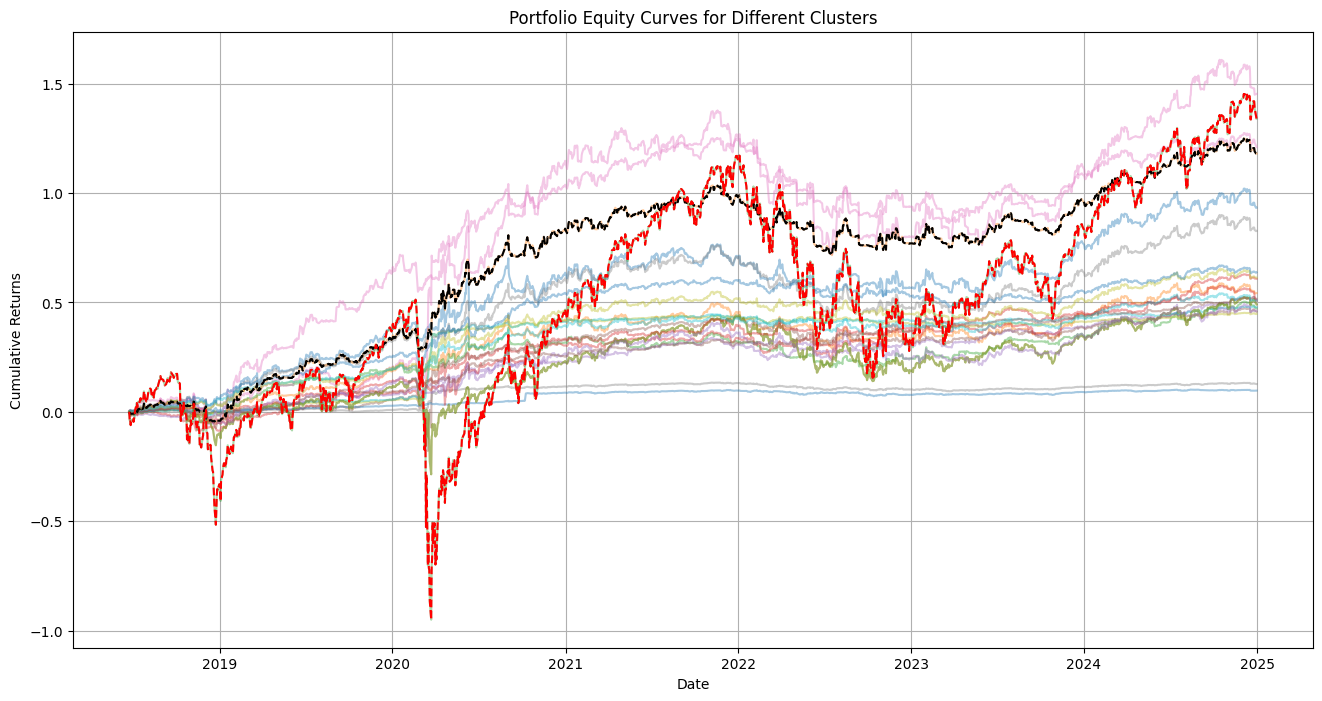

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.figure(figsize=(16, 8))

# Select equity curve columns
equity_cols = [col for col in df_portfolios_train.columns if 'equity_curve' in col]

for col in equity_cols:
    # Prepend a zero to the equity curve
    curve = df_portfolios_train[col]
    curve_with_zero = pd.concat(
        [pd.Series([0], index=[curve.index[0] - pd.Timedelta(days=1)]), curve]
    )
    plt.plot(curve_with_zero.index, curve_with_zero.values, label=col, alpha=0.4)

# Overlay portfolio equity curve
if 'Portfolio_equity_curve' in df_portfolios_train.columns:
    curve = df_portfolios_train['Portfolio_equity_curve']
    curve_with_zero = pd.concat(
        [pd.Series([0], index=[curve.index[0] - pd.Timedelta(days=1)]), curve]
    )
    plt.plot(curve_with_zero.index, curve_with_zero.values, linestyle='--', color='black', label="Portfolio")


if 'BENCH_equity_curve' in df_portfolios_train.columns:
    curve = df_portfolios_train['BENCH_equity_curve']
    curve_with_zero = pd.concat(
        [pd.Series([0], index=[curve.index[0] - pd.Timedelta(days=1)]), curve]
    )
    plt.plot(curve_with_zero.index, curve_with_zero.values, linestyle='--', color='red', label="Portfolio")


#plt.plot(curve_with_zero.index, df_portfolios_train['BENCH_equity_curve'], linestyle='--', color='red', label="Portfolio")

plt.title("Portfolio Equity Curves for Different Clusters")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
#plt.legend()
plt.grid(True)
plt.show()

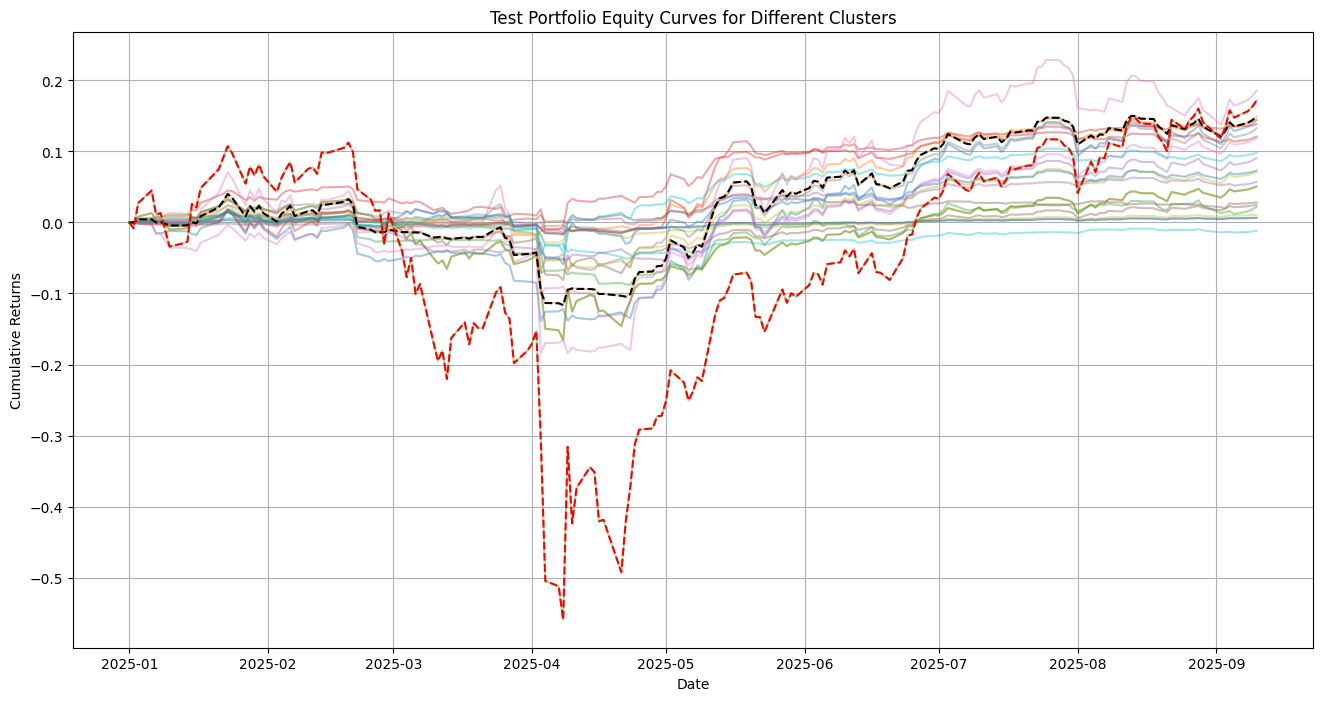

In [ ]:
plt.figure(figsize=(16, 8))

# Select equity curve columns in test set
equity_cols_test = [col for col in df_portfolios_test.columns if 'equity_curve' in col]

for col in equity_cols_test:
    # Prepend a zero to the equity curve
    curve = df_portfolios_test[col]
    curve_with_zero = pd.concat(
        [pd.Series([0], index=[curve.index[0] - pd.Timedelta(days=1)]), curve]
    )
    plt.plot(curve_with_zero.index, curve_with_zero.values, label=col, alpha=0.4)

# Overlay portfolio equity curve
if 'Portfolio_equity_curve' in df_portfolios_test.columns:
    curve = df_portfolios_test['Portfolio_equity_curve']
    curve_with_zero = pd.concat(
        [pd.Series([0], index=[curve.index[0] - pd.Timedelta(days=1)]), curve]
    )
    plt.plot(curve_with_zero.index, curve_with_zero.values, linestyle='--', color='black', label="Portfolio")


if 'BENCH_equity_curve' in df_portfolios_test.columns:
    curve = df_portfolios_test['BENCH_equity_curve']
    curve_with_zero = pd.concat(
        [pd.Series([0], index=[curve.index[0] - pd.Timedelta(days=1)]), curve]
    )
    plt.plot(curve_with_zero.index, curve_with_zero.values, linestyle='--', color='red', label="Portfolio")



plt.title("Test Portfolio Equity Curves for Different Clusters")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
#plt.legend()
plt.grid(True)
plt.show()


## Portfolio

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def build_markowitz_portfolios(df_train, df_test, freq=252, rf=0.0, min_alloc=0.0, allow_short=False):
    """
    Build Minimum Variance and Tangency Portfolios from log return columns.

    Args:
        df_train (pd.DataFrame): Train set with '_returns' columns
        df_test (pd.DataFrame): Test set with '_returns' columns
        freq (int): Annualization factor (default 252 for daily returns)
        rf (float): Risk-free rate (annualized)
        min_alloc (float): Minimum allocation for long positions
        allow_short (bool): Whether to allow short positions (negative weights)

    Returns:
        df_train_out, df_test_out, weights_mvp, weights_tangency
    """
    df_train_out = df_train.copy()
    df_test_out  = df_test.copy()

    # --- Select return columns ---
    return_cols_train = [c for c in df_train_out.columns if "_returns" in c]
    return_cols_test  = [c for c in df_test_out.columns if "_returns" in c]

    returns_train = df_train_out[return_cols_train]
    returns_test  = df_test_out[return_cols_test]

    # --- Train statistics ---
    mu = returns_train.mean()
    cov = returns_train.cov()

    # --- Set bounds based on min allocation and shorting ---
    if allow_short:
        bounds = tuple((-1, 1) for _ in range(len(mu)))  # allow full short
    else:
        bounds = tuple((min_alloc, 1.0) for _ in range(len(mu)))  # long-only with min allocation

    # Constraint: fully invested
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

    init_guess = np.ones(len(mu)) / len(mu)

    # --- Minimum Variance Portfolio ---
    def portfolio_variance(weights, cov):
        return weights.T @ cov.values @ weights

    res_mvp = minimize(portfolio_variance, init_guess, args=(cov,), method='SLSQP', bounds=bounds, constraints=constraints)
    weights_mvp = pd.Series(res_mvp.x, index=return_cols_train)

    # --- Tangency Portfolio ---
    def neg_sharpe(weights, mu, cov, freq=freq, rf=rf):
        port_return = np.sum(weights * mu) * freq
        port_vol = np.sqrt(weights.T @ cov.values @ weights) * np.sqrt(freq)
        return -(port_return - rf) / port_vol

    res_tangency = minimize(neg_sharpe, init_guess, args=(mu, cov), method='SLSQP', bounds=bounds, constraints=constraints)
    weights_tangency = pd.Series(res_tangency.x, index=return_cols_train)

    # --- Portfolio returns & equity curves ---
    df_train_out['mvp_portfolio_returns'] = returns_train @ weights_mvp
    df_train_out['mvp_portfolio_equity_curve'] = df_train_out['mvp_portfolio_returns'].cumsum()

    df_train_out['tangency_portfolio_returns'] = returns_train @ weights_tangency
    df_train_out['tangency_portfolio_equity_curve'] = df_train_out['tangency_portfolio_returns'].cumsum()

    df_test_out['mvp_portfolio_returns'] = returns_test @ weights_mvp
    df_test_out['mvp_portfolio_equity_curve'] = df_test_out['mvp_portfolio_returns'].cumsum()

    df_test_out['tangency_portfolio_returns'] = returns_test @ weights_tangency
    df_test_out['tangency_portfolio_equity_curve'] = df_test_out['tangency_portfolio_returns'].cumsum()

    return df_train_out, df_test_out, weights_mvp, weights_tangency


In [ ]:
df_portfolios_train_2, df_portfolios_test_2, w_mvp, w_tangency = build_markowitz_portfolios(
    df_portfolios_train, df_portfolios_test
)

#print("MVP Weights:\n", w_mvp)
#print("\nTangency Weights:\n", w_tangency)



In [ ]:
df_metrics_train_2 = Calculate_fin_metrics(df_portfolios_train_2)
df_metrics_test_2 = Calculate_fin_metrics(df_portfolios_test_2)

In [ ]:
df_metrics_train_2 = df_metrics_train_2.sort_values(by="Sharpe Ratio", ascending=False)  # lowest vol first

df_metrics_train_2

,Total Return,Annualized Return,Volatility,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown,CAGR,Skewness,Kurtosis,VaR 95%,CVaR 95%,Hit Ratio
Column,,,,,,,,,,,,,,
tangency_portfolio,0.330,0.052,0.002,0.025,2.008,3.041,2.180,0.024,0.052,1.322,10.930,-0.002,-0.003,0.548
Cluster_AffinityProp,0.516,0.083,0.003,0.050,1.600,2.178,1.609,0.051,0.083,0.338,10.547,-0.004,-0.007,0.540
Cluster_SP9,0.448,0.071,0.003,0.045,1.513,3.064,1.271,0.056,0.071,5.460,54.621,-0.003,-0.004,0.558
Cluster_SP12,0.478,0.076,0.003,0.051,1.449,2.654,1.618,0.047,0.076,5.622,60.073,-0.003,-0.005,0.553
Cluster_KM12,0.512,0.082,0.004,0.065,1.215,1.566,0.773,0.106,0.082,-0.127,5.052,-0.006,-0.010,0.552
Cluster_Birch12,0.638,0.103,0.006,0.090,1.094,1.445,0.767,0.134,0.103,0.053,7.381,-0.008,-0.013,0.551
Cluster_KM9,0.608,0.098,0.006,0.088,1.063,1.350,0.770,0.127,0.098,0.103,9.289,-0.007,-0.013,0.537
Portfolio,1.181,0.199,0.011,0.176,1.029,1.243,0.624,0.319,0.199,-0.520,7.786,-0.017,-0.027,0.548
Cluster_Birch9,0.508,0.081,0.005,0.080,0.974,1.205,1.029,0.079,0.081,-0.346,9.279,-0.007,-0.012,0.550


In [ ]:
df_metrics_test_2 = df_metrics_test_2.sort_values(by="Sharpe Ratio", ascending=False)  # lowest vol first

df_metrics_test_2

,Total Return,Annualized Return,Volatility,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown,CAGR,Skewness,Kurtosis,VaR 95%,CVaR 95%,Hit Ratio
Column,,,,,,,,,,,,,,
Cluster_KM5,0.145,0.237,0.007,0.105,2.015,2.775,6.118,0.039,0.237,0.239,4.495,-0.009,-0.015,0.535
Cluster_KM9,0.121,0.194,0.006,0.094,1.894,2.528,3.231,0.060,0.194,0.752,10.690,-0.007,-0.013,0.558
Cluster_BayesGMM,0.138,0.225,0.007,0.111,1.823,2.867,5.826,0.039,0.225,2.843,24.374,-0.007,-0.013,0.547
Cluster_Birch9,0.098,0.155,0.006,0.097,1.487,1.938,2.499,0.062,0.155,0.780,18.813,-0.006,-0.013,0.535
Cluster_KM12,0.057,0.088,0.004,0.057,1.463,2.048,2.139,0.041,0.088,0.443,4.703,-0.005,-0.008,0.558
Portfolio,0.149,0.244,0.011,0.176,1.240,1.570,1.559,0.157,0.244,-0.162,6.943,-0.015,-0.026,0.529
Cluster_Birch5,0.132,0.214,0.010,0.158,1.227,1.453,2.024,0.106,0.214,-1.037,6.029,-0.013,-0.025,0.541
Cluster_AffinityProp-50,0.091,0.142,0.007,0.112,1.188,1.709,2.014,0.070,0.142,0.418,5.365,-0.010,-0.016,0.506
Cluster_KM3,0.144,0.235,0.012,0.189,1.118,1.446,1.504,0.156,0.235,-0.128,5.825,-0.016,-0.028,0.517
